# Bank Marketing Conversion Prediction Using Machine Learning


## 1. Configuration and reproducibility

Fast mode uses fewer search iterations and bootstrap repetitions while retaining every analytical stage. Full mode increases the statistical and tuning budgets. All preprocessing is fitted inside each cross-validation fold.


In [ ]:
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 905.3 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 20.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 58.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 40.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 7.3 MB/s eta 0:00:00


In [ ]:
import os
import sys
import json
import time
import shutil
import random
import warnings
import platform
import importlib.metadata as metadata
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset, ClassLabel
import sklearn
import shap
import mlflow
import mlflow.sklearn
import joblib

# Enable MLflow before importing sklearn.metrics, as recommended by MLflow.
IN_COLAB = "google.colab" in sys.modules or Path("/content").exists()
if IN_COLAB:
    from google.colab import userdata

PROJECT_ROOT = Path("/content/bank_marketing_project" if IN_COLAB else "bank_marketing_project")
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "models"
HYPOTHESIS_DIR = OUTPUT_DIR / "hypotheses"
MLFLOW_DIR = PROJECT_ROOT / "mlruns"
MLFLOW_DB = PROJECT_ROOT / "mlflow.db"
for folder in [PROJECT_ROOT, OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, MODEL_DIR, HYPOTHESIS_DIR, MLFLOW_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

FAST_MODE = True                 # Change to False for the final, longer research run.
RANDOM_STATE = 42
CV_SPLITS = 3 if FAST_MODE else 5
SEARCH_ITERATIONS = 8 if FAST_MODE else 30
ABLATION_ITERATIONS = 5 if FAST_MODE else 20
BOOTSTRAP_REPETITIONS = 300 if FAST_MODE else 2000
PERMUTATION_REPETITIONS = 20 if FAST_MODE else 100
SHAP_SAMPLE_SIZE = 400 if FAST_MODE else 1000
AUTO_DOWNLOAD_RESULTS = False    # Set True if the final ZIP should download automatically.
N_JOBS = 2 if IN_COLAB else 1    # Avoid memory-heavy nested parallelism on standard Colab runtimes.

# Retrieve HF_TOKEN from secrets if in Colab, otherwise environment variables.
HF_TOKEN = os.getenv("HF_TOKEN")
if IN_COLAB and not HF_TOKEN:
    try:
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        HF_TOKEN = None  # The referenced Hugging Face dataset is public.

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB.resolve()}")
experiment_name = "bank_marketing_conversion_prediction"
if mlflow.get_experiment_by_name(experiment_name) is None:
    mlflow.create_experiment(experiment_name, artifact_location=MLFLOW_DIR.resolve().as_uri())
mlflow.set_experiment(experiment_name)
mlflow.sklearn.autolog(
    # Tuning metadata and CV results are autologged; only the final evaluated models are saved below.
    log_models=False,
    log_datasets=True,
    max_tuning_runs=10,
    silent=True,
    disable_for_unsupported_versions=False,
)

PACKAGE_NAMES = ["datasets", "pandas", "numpy", "scikit-learn", "scipy", "shap", "mlflow", "matplotlib", "seaborn", "joblib"]
environment = {
    "python": sys.version,
    "platform": platform.platform(),
    "processor": platform.processor(),
    "fast_mode": FAST_MODE,
    "random_state": RANDOM_STATE,
    "packages": {name: metadata.version(name) for name in PACKAGE_NAMES},
}
print(json.dumps(environment, indent=2))
print(f"Project directory: {PROJECT_ROOT}")

2026/08/06 03:11:43 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/06 03:11:43 INFO mlflow.store.db.utils: Updating database tables


{
  "python": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "platform": "Linux-6.12.90+-x86_64-with-glibc2.35",
  "processor": "x86_64",
  "fast_mode": true,
  "random_state": 42,
  "packages": {
    "datasets": "5.0.0",
    "pandas": "2.3.3",
    "numpy": "2.0.2",
    "scikit-learn": "1.6.1",
    "scipy": "1.16.3",
    "shap": "0.51.0",
    "mlflow": "3.15.1",
    "matplotlib": "3.10.0",
    "seaborn": "0.13.2",
    "joblib": "1.5.3"
  }
}
Project directory: /content/bank_marketing_project


## 2. Load and decode the Hugging Face dataset

The repository currently exposes categorical variables as Hugging Face `ClassLabel` integers. The code decodes every such variable from its metadata instead of treating category codes as numerical magnitudes. A token is read only from the `HF_TOKEN` environment variable if public loading fails.


In [ ]:
DATASET_ID = "cestwc/bank-marketing"

try:
    dataset_dict = load_dataset(DATASET_ID)
except Exception as public_error:
    if not HF_TOKEN:
        raise RuntimeError(
            "Public loading failed. Check internet access, or add HF_TOKEN to Colab Secrets "
            "if Hugging Face requests authentication."
        ) from public_error
    dataset_dict = load_dataset(DATASET_ID, token=HF_TOKEN)

if "train" not in dataset_dict:
    raise KeyError(f"Expected a train split; found {list(dataset_dict.keys())}")

hf_data = dataset_dict["train"]
dataset_fingerprint = getattr(hf_data, "_fingerprint", "unavailable")
feature_schema = hf_data.features
data = hf_data.to_pandas().copy()
data.insert(0, "row_id", np.arange(len(data), dtype=int))

decoded_columns = []
for column, feature in feature_schema.items():
    if isinstance(feature, ClassLabel):
        valid_codes = set(range(len(feature.names)))
        def decode_label(value, class_feature=feature):
            if pd.isna(value):
                return np.nan
            code_value = int(value)
            return class_feature.int2str(code_value) if code_value in valid_codes else f"unmapped_{code_value}"
        data[column] = data[column].map(decode_label).astype("object")
        decoded_columns.append(column)

if "y" not in data.columns:
    raise KeyError("Target column 'y' was not found.")
target_levels = sorted(data["y"].dropna().astype(str).unique().tolist())
if "yes" not in target_levels or "no" not in target_levels:
    raise ValueError(f"Expected target labels no/yes, found {target_levels}")
data["target"] = (data["y"].astype(str) == "yes").astype(int)

expected_columns = {
    "age", "job", "marital", "education", "default", "balance", "housing", "loan",
    "contact", "day", "month", "duration", "campaign", "pdays", "previous", "poutcome", "y"
}
missing_expected = expected_columns.difference(data.columns)
if missing_expected:
    raise KeyError(f"Missing expected columns: {sorted(missing_expected)}")

print(f"Splits: {list(dataset_dict.keys())}")
print(f"Rows: {len(data):,}; original fields: {len(feature_schema)}; fingerprint: {dataset_fingerprint}")
print(f"Decoded ClassLabel fields: {decoded_columns}")
print(f"Target levels: {target_levels}; positive prevalence: {data['target'].mean():.3%}")
display(data.head())

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-f26fa3adaf6dfd(…):   0%|          | 0.00/693k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45211 [00:00<?, ? examples/s]

Splits: ['train']
Rows: 45,211; original fields: 17; fingerprint: 3b3541a66637b6cc
Decoded ClassLabel fields: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
Target levels: ['no', 'yes']; positive prevalence: 11.698%


,row_id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,target
0,0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,999,0,unknown,no,0
1,1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,999,0,unknown,no,0
2,2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,999,0,unknown,no,0
3,3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,999,0,unknown,no,0
4,4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,999,0,unknown,no,0


## 3. Data-quality checks and `pdays` correction

The source conversion replaces the original `pdays=-1` “not previously contacted” sentinel with `999`. The value is therefore separated into an availability indicator and a meaningful elapsed-days field. Exact duplicates are reported but not removed automatically because repeated campaign records may be legitimate.


In [ ]:
duplicate_columns = [c for c in data.columns if c not in ["row_id", "target"]]
exact_duplicates = int(data.duplicated(subset=duplicate_columns).sum())

never_contacted = data["pdays"].isin([-1, 999])
data["previously_contacted"] = (~never_contacted).astype(int)
data["pdays_since_previous"] = pd.to_numeric(data["pdays"], errors="coerce").mask(never_contacted, np.nan)

quality_rows = []
for column in data.columns:
    series = data[column]
    quality_rows.append({
        "column": column,
        "dtype": str(series.dtype),
        "missing_n": int(series.isna().sum()),
        "missing_pct": float(series.isna().mean() * 100),
        "unique_n": int(series.nunique(dropna=True)),
        "unknown_n": int((series.astype(str).str.lower() == "unknown").sum()) if series.dtype == "object" else 0,
    })
quality_table = pd.DataFrame(quality_rows)
quality_table.to_csv(TABLE_DIR / "data_quality.csv", index=False)

range_checks = {
    "age_below_18": int((data["age"] < 18).sum()),
    "age_above_100": int((data["age"] > 100).sum()),
    "negative_duration": int((data["duration"] < 0).sum()),
    "campaign_below_1": int((data["campaign"] < 1).sum()),
    "pdays_sentinel_999": int((data["pdays"] == 999).sum()),
    "exact_duplicate_rows_not_removed": exact_duplicates,
}
with open(TABLE_DIR / "range_checks.json", "w") as file:
    json.dump(range_checks, file, indent=2)

print(json.dumps(range_checks, indent=2))
display(quality_table)
display(data.describe(include="all").transpose().head(25))

{
  "age_below_18": 0,
  "age_above_100": 0,
  "negative_duration": 0,
  "campaign_below_1": 0,
  "pdays_sentinel_999": 36954,
  "exact_duplicate_rows_not_removed": 0
}


,column,dtype,missing_n,missing_pct,unique_n,unknown_n
0,row_id,int64,0,0.0000,45211,0
1,age,int64,0,0.0000,77,0
2,job,object,0,0.0000,12,288
3,marital,object,0,0.0000,3,0
4,education,object,0,0.0000,4,1857
5,default,object,0,0.0000,2,0
6,balance,int64,0,0.0000,7168,0
7,housing,object,0,0.0000,2,0
8,loan,object,0,0.0000,2,0
9,contact,object,0,0.0000,3,13020


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
row_id,"45,211.0000",NaN,NaN,NaN,"22,605.0000","13,051.4358",0.0000,"11,302.5000","22,605.0000","33,907.5000","45,210.0000"
age,"45,211.0000",NaN,NaN,NaN,40.9362,10.6188,18.0000,33.0000,39.0000,48.0000,95.0000
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,"45,211.0000",NaN,NaN,NaN,"1,362.2721","3,044.7658","-8,019.0000",72.0000,448.0000,"1,428.0000","102,127.0000"
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Exploratory analysis

These plots describe observed associations only. They do not show that changing a customer attribute or contact strategy will cause conversion.


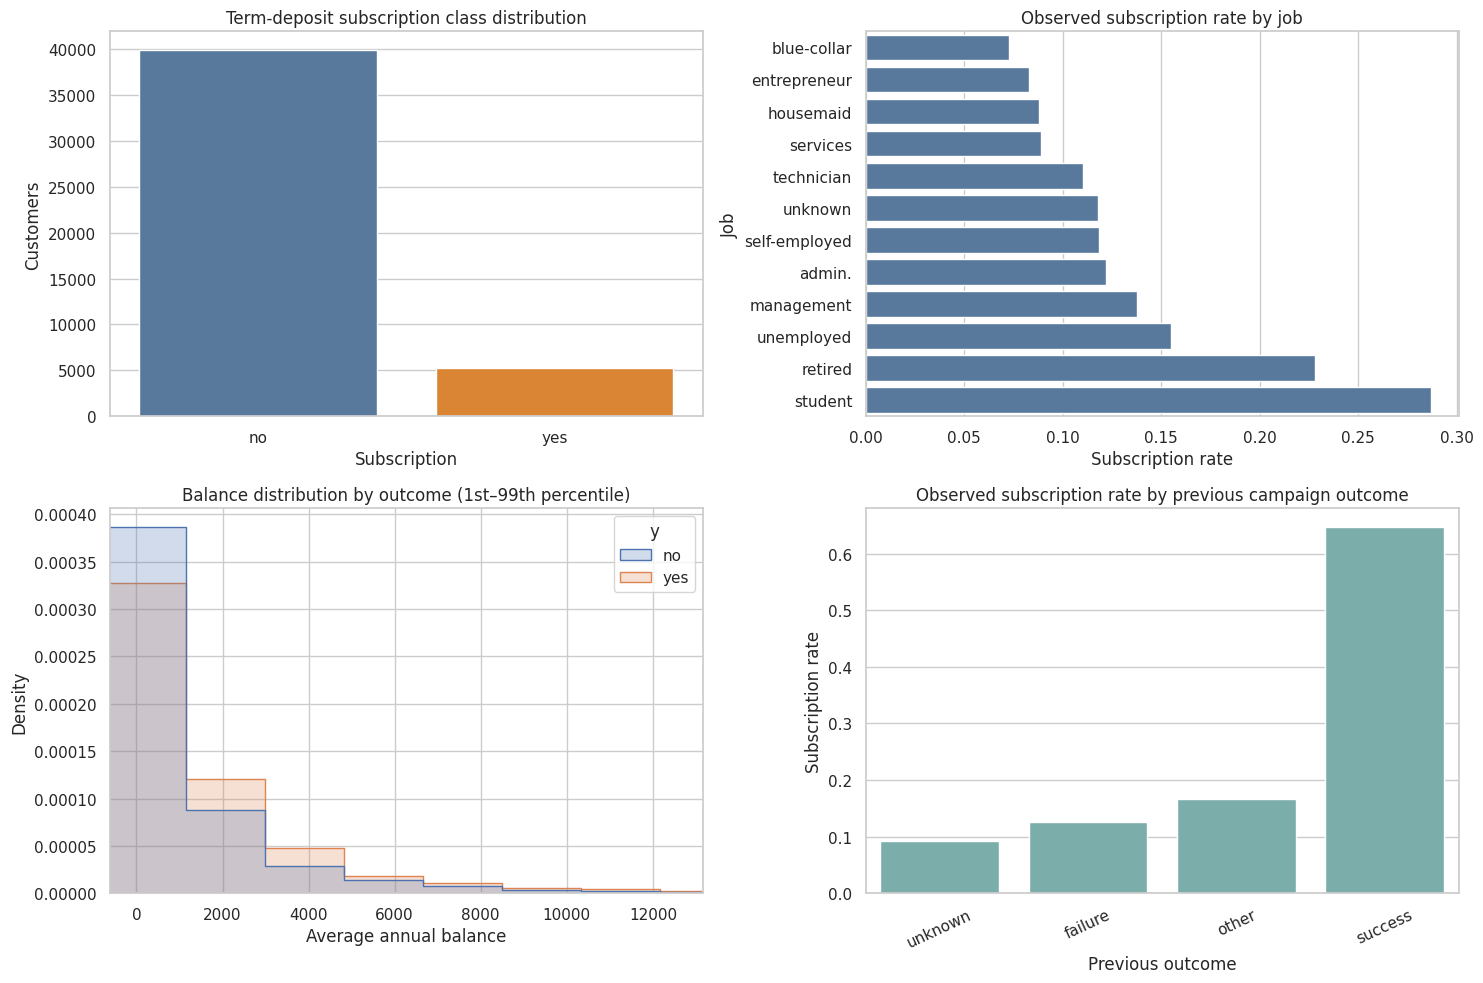

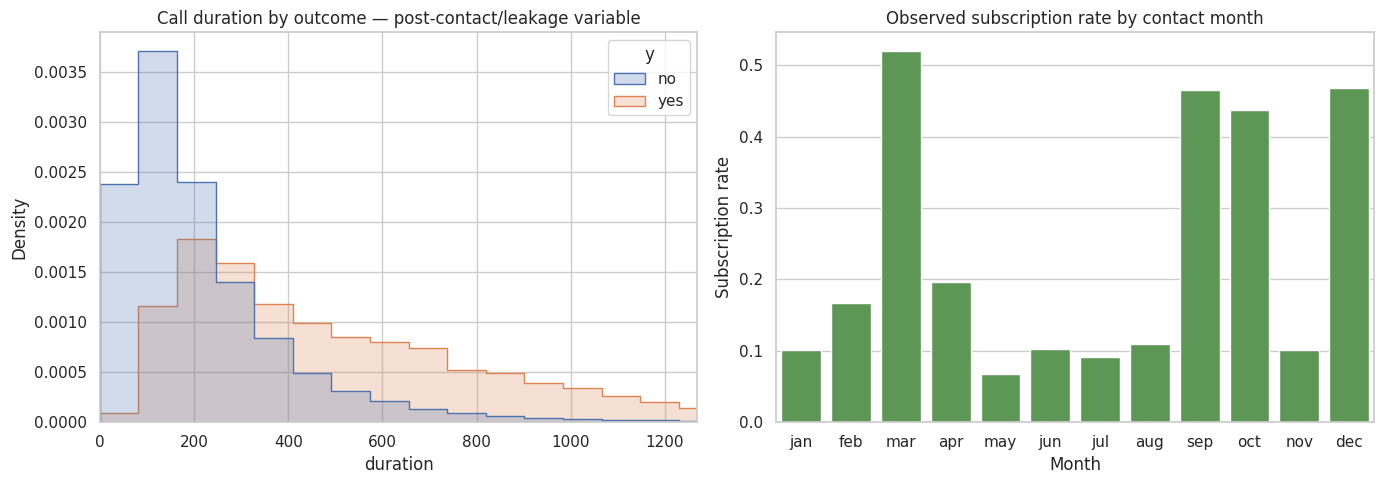

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

target_counts = data["y"].value_counts().reindex(["no", "yes"])
sns.barplot(x=target_counts.index, y=target_counts.values, ax=axes[0, 0], palette=["#4C78A8", "#F58518"])
axes[0, 0].set(title="Term-deposit subscription class distribution", xlabel="Subscription", ylabel="Customers")

job_rates = data.groupby("job", observed=True)["target"].agg(["mean", "count"]).query("count >= 100").sort_values("mean")
sns.barplot(x=job_rates["mean"], y=job_rates.index, ax=axes[0, 1], color="#4C78A8")
axes[0, 1].set(title="Observed subscription rate by job", xlabel="Subscription rate", ylabel="Job")

sns.histplot(data=data, x="balance", hue="y", bins=60, element="step", stat="density", common_norm=False, ax=axes[1, 0])
axes[1, 0].set_xlim(data["balance"].quantile(0.01), data["balance"].quantile(0.99))
axes[1, 0].set(title="Balance distribution by outcome (1st–99th percentile)", xlabel="Average annual balance", ylabel="Density")

poutcome_rates = data.groupby("poutcome", observed=True)["target"].agg(["mean", "count"]).sort_values("mean")
sns.barplot(x=poutcome_rates.index, y=poutcome_rates["mean"], ax=axes[1, 1], color="#72B7B2")
axes[1, 1].set(title="Observed subscription rate by previous campaign outcome", xlabel="Previous outcome", ylabel="Subscription rate")
axes[1, 1].tick_params(axis="x", rotation=25)

plt.tight_layout()
eda_path = FIGURE_DIR / "eda_overview.png"
plt.savefig(eda_path, dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=data, x="duration", hue="y", bins=60, element="step", stat="density", common_norm=False, ax=axes[0])
axes[0].set_xlim(0, data["duration"].quantile(0.99))
axes[0].set_title("Call duration by outcome — post-contact/leakage variable")

month_order = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
month_rates = data.groupby("month", observed=True)["target"].mean().reindex(month_order)
sns.barplot(x=month_rates.index, y=month_rates.values, ax=axes[1], color="#54A24B")
axes[1].set(title="Observed subscription rate by contact month", xlabel="Month", ylabel="Subscription rate")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "contact_eda.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Feature availability and leakage audit

The strict model uses customer and previous-campaign information available before the current call. The no-duration set is a diagnostic benchmark, while the full set deliberately includes duration to quantify inflated performance.


In [ ]:
STRICT_FEATURES = [
    "age", "job", "marital", "education", "default", "balance", "housing", "loan",
    "previous", "previously_contacted", "pdays_since_previous", "poutcome",
]
NO_DURATION_FEATURES = [
    c for c in [
        "age", "job", "marital", "education", "default", "balance", "housing", "loan",
        "contact", "day", "month", "campaign", "previous", "poutcome"
    ]
] + ["previously_contacted", "pdays_since_previous"]
FULL_FEATURES = NO_DURATION_FEATURES + ["duration"]

availability = {
    "age": ("customer", "before call", True, "none identified"),
    "job": ("customer", "before call", True, "potential sensitivity/proxy"),
    "marital": ("customer", "before call", True, "potential sensitivity"),
    "education": ("customer", "before call", True, "potential socioeconomic proxy"),
    "default": ("customer", "before call", True, "financial vulnerability concern"),
    "balance": ("customer", "before call", True, "financial-status concern"),
    "housing": ("customer", "before call", True, "financial-status proxy"),
    "loan": ("customer", "before call", True, "financial-status proxy"),
    "previous": ("history", "before call", True, "historical campaign dependence"),
    "previously_contacted": ("history", "before call", True, "derived from pdays sentinel"),
    "pdays_since_previous": ("history", "before call", True, "undefined for never-contacted customers"),
    "poutcome": ("history", "before call", True, "historical campaign selection"),
    "contact": ("current campaign", "at current contact", False, "availability depends on scoring point"),
    "day": ("current campaign", "at current contact", False, "post-selection/current-campaign information"),
    "month": ("current campaign", "at current contact", False, "post-selection/current-campaign information"),
    "campaign": ("current campaign", "during campaign", False, "includes current contact"),
    "duration": ("current call", "during/after call", False, "direct post-contact leakage"),
}
audit_rows = []
for feature in FULL_FEATURES:
    group, available, deployable, concern = availability[feature]
    audit_rows.append({
        "feature": feature,
        "group": group,
        "available_at": available,
        "strict_precontact": deployable,
        "leakage_or_responsibility_concern": concern,
    })
feature_audit = pd.DataFrame(audit_rows)
feature_audit.to_csv(TABLE_DIR / "feature_availability_audit.csv", index=False)
display(feature_audit)

,feature,group,available_at,strict_precontact,leakage_or_responsibility_concern
0,age,customer,before call,True,none identified
1,job,customer,before call,True,potential sensitivity/proxy
2,marital,customer,before call,True,potential sensitivity
3,education,customer,before call,True,potential socioeconomic proxy
4,default,customer,before call,True,financial vulnerability concern
5,balance,customer,before call,True,financial-status concern
6,housing,customer,before call,True,financial-status proxy
7,loan,customer,before call,True,financial-status proxy
8,contact,current campaign,at current contact,False,availability depends on scoring point
9,day,current campaign,at current contact,False,post-selection/current-campaign information


## 6. Order-based development, calibration, threshold and test splits

The original file is reported as date ordered but lacks a complete timestamp. Row order is therefore used as a temporal proxy, not claimed as a genuine out-of-time test. Within development data, expanding-window cross-validation avoids training on later rows and validating on earlier rows.


In [ ]:
from sklearn.model_selection import TimeSeriesSplit

n_rows = len(data)
train_end = int(n_rows * 0.70)
validation_end = int(n_rows * 0.85)
calibration_end = train_end + (validation_end - train_end) // 2

INDEX = {
    "train": np.arange(0, train_end),
    "calibration": np.arange(train_end, calibration_end),
    "threshold": np.arange(calibration_end, validation_end),
    "test": np.arange(validation_end, n_rows),
}

split_summary = []
for split_name, split_index in INDEX.items():
    split_summary.append({
        "split": split_name,
        "start_row": int(split_index.min()),
        "end_row": int(split_index.max()),
        "n": len(split_index),
        "positive_n": int(data.loc[split_index, "target"].sum()),
        "positive_rate": float(data.loc[split_index, "target"].mean()),
    })
split_summary = pd.DataFrame(split_summary)
split_summary.to_csv(TABLE_DIR / "split_summary.csv", index=False)
display(split_summary)

def valid_time_series_cv(y_values, requested_splits):
    for n_splits in range(requested_splits, 1, -1):
        splitter = TimeSeriesSplit(n_splits=n_splits)
        valid = True
        for train_indices, validation_indices in splitter.split(np.zeros(len(y_values))):
            if len(np.unique(y_values.iloc[train_indices])) < 2 or len(np.unique(y_values.iloc[validation_indices])) < 2:
                valid = False
                break
        if valid:
            return splitter
    raise ValueError("No expanding-window split contains both classes in every fold.")

y_train = data.loc[INDEX["train"], "target"].reset_index(drop=True)
temporal_cv = valid_time_series_cv(y_train, CV_SPLITS)
print(f"Using {temporal_cv.n_splits} expanding-window CV folds.")

,split,start_row,end_row,n,positive_n,positive_rate
0,train,0,31646,31647,1840,0.0581
1,calibration,31647,35037,3391,526,0.1551
2,threshold,35038,38428,3391,255,0.0752
3,test,38429,45210,6782,2668,0.3934


Using 3 expanding-window CV folds.


In [ ]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_validate, train_test_split
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve, roc_curve, auc,
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    fbeta_score, matthews_corrcoef, cohen_kappa_score, confusion_matrix,
    brier_score_loss, log_loss, classification_report, make_scorer
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance

def column_types(frame, features):
    categorical = [c for c in features if frame[c].dtype == "object" or str(frame[c].dtype).startswith("category")]
    numerical = [c for c in features if c not in categorical]
    return numerical, categorical

def make_preprocessor(frame, features, dense=False, scale_numeric=False):
    numerical, categorical = column_types(frame, features)
    numeric_steps = [("imputer", SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    numeric_pipeline = Pipeline(numeric_steps)
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=not dense)),
    ])
    return ColumnTransformer(
        [("num", numeric_pipeline, numerical), ("cat", categorical_pipeline, categorical)],
        remainder="drop",
        sparse_threshold=0.0 if dense else 0.3,
        verbose_feature_names_out=True,
    )

def model_and_space(model_name, frame, features):
    if model_name == "Dummy":
        model = DummyClassifier(strategy="prior")
        params = {}
        dense, scale = False, False
    elif model_name == "LogisticRegression":
        model = LogisticRegression(max_iter=2500, solver="liblinear", random_state=RANDOM_STATE)
        params = {
            "model__C": np.logspace(-3, 2, 12),
            "model__class_weight": [None, "balanced"],
        }
        dense, scale = False, True
    elif model_name == "DecisionTree":
        model = DecisionTreeClassifier(random_state=RANDOM_STATE)
        params = {
            "model__criterion": ["gini", "entropy", "log_loss"],
            "model__max_depth": [3, 5, 8, 12, 18, None],
            "model__min_samples_split": [2, 10, 30, 60],
            "model__min_samples_leaf": [1, 5, 15, 40],
            "model__class_weight": [None, "balanced"],
        }
        dense, scale = False, False
    elif model_name == "RandomForest":
        # SearchCV owns parallelism; keeping the forest single-threaded avoids nested CPU oversubscription in Colab.
        model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)
        params = {
            "model__n_estimators": [150, 250, 400],
            "model__max_depth": [5, 8, 12, 18, None],
            "model__min_samples_split": [2, 10, 30],
            "model__min_samples_leaf": [1, 3, 10, 25],
            "model__max_features": ["sqrt", "log2", 0.7],
            "model__class_weight": [None, "balanced", "balanced_subsample"],
        }
        dense, scale = False, False
    elif model_name == "ExtraTrees":
        model = ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=1)
        params = {
            "model__n_estimators": [150, 250, 400],
            "model__max_depth": [5, 8, 12, 18, None],
            "model__min_samples_split": [2, 10, 30],
            "model__min_samples_leaf": [1, 3, 10, 25],
            "model__max_features": ["sqrt", "log2", 0.7, 1.0],
            "model__class_weight": [None, "balanced", "balanced_subsample"],
        }
        dense, scale = False, False
    elif model_name == "HistGradientBoosting":
        model = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
        params = {
            "model__learning_rate": [0.025, 0.05, 0.1, 0.2],
            "model__max_iter": [100, 200, 300],
            "model__max_leaf_nodes": [7, 15, 31, 63],
            "model__max_depth": [None, 4, 8, 12],
            "model__min_samples_leaf": [10, 20, 40, 80],
            "model__l2_regularization": [0.0, 0.1, 1.0, 5.0],
            "model__class_weight": [None, "balanced"],
        }
        dense, scale = True, False
    else:
        raise KeyError(model_name)

    pipeline = Pipeline([
        ("preprocess", make_preprocessor(frame, features, dense=dense, scale_numeric=scale)),
        ("model", model),
    ])
    return pipeline, params

SCORING = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "f1": make_scorer(f1_score, zero_division=0),
    "neg_log_loss": "neg_log_loss",
}
MODEL_NAMES = ["Dummy", "LogisticRegression", "DecisionTree", "RandomForest", "ExtraTrees", "HistGradientBoosting"]


Training Dummy ...

Training LogisticRegression ...

Training DecisionTree ...

Training RandomForest ...

Training ExtraTrees ...

Training HistGradientBoosting ...


,model,cv_average_precision_mean,cv_average_precision_sd,cv_roc_auc_mean,fit_seconds,best_params
1,LogisticRegression,0.0866,0.0261,0.5672,11.1348,"{""model__class_weight"": ""balanced"", ""model__C""..."
3,RandomForest,0.0863,0.0313,0.5611,90.9442,"{""model__n_estimators"": 250, ""model__min_sampl..."
5,HistGradientBoosting,0.0844,0.0274,0.5564,23.4433,"{""model__min_samples_leaf"": 40, ""model__max_le..."
4,ExtraTrees,0.0808,0.0203,0.5435,108.9065,"{""model__n_estimators"": 150, ""model__min_sampl..."
2,DecisionTree,0.0808,0.0287,0.5482,8.8080,"{""model__min_samples_split"": 30, ""model__min_s..."
0,Dummy,0.0669,0.0201,0.5000,7.9092,{}


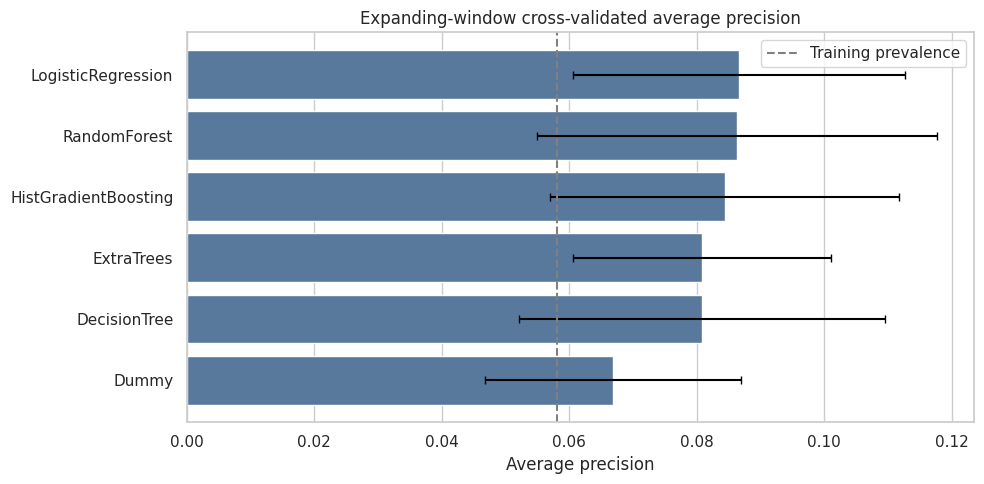

In [ ]:
def fit_candidates(features, run_prefix="strict_precontact", search_iterations=SEARCH_ITERATIONS):
    X_development = data.loc[INDEX["train"], features].reset_index(drop=True)
    y_development = data.loc[INDEX["train"], "target"].reset_index(drop=True)
    fitted = {}
    cv_tables = {}
    leaderboard_rows = []

    # Scoring dictionary using valid parameters for each scorer.
    # UndefinedMetricWarning will be handled via a warnings filter below.
    LOCAL_SCORING = {
        "average_precision": "average_precision",
        "roc_auc": "roc_auc",
        "balanced_accuracy": "balanced_accuracy",
        "precision": make_scorer(precision_score, zero_division=0),
        "recall": make_scorer(recall_score, zero_division=0),
        "f1": make_scorer(f1_score, zero_division=0),
        "neg_log_loss": "neg_log_loss",
    }

    for model_name in MODEL_NAMES:
        print(f"\nTraining {model_name} ...")
        pipeline, parameter_space = model_and_space(model_name, data, features)
        run_name = f"{run_prefix}_{model_name}"
        start = time.time()

        # Suppress UndefinedMetricWarning during the fit and CV process
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=sklearn.exceptions.UndefinedMetricWarning)
            with mlflow.start_run(run_name=run_name):
                mlflow.set_tags({"feature_set": run_prefix, "split": "row_order_temporal_proxy", "fast_mode": str(FAST_MODE)})
                mlflow.log_params({"dataset_id": DATASET_ID, "dataset_fingerprint": dataset_fingerprint, "n_features_raw": len(features)})

                if model_name == "Dummy":
                    cv_result = cross_validate(
                        pipeline, X_development, y_development, cv=temporal_cv,
                        scoring=LOCAL_SCORING, n_jobs=N_JOBS, return_train_score=True, error_score="raise"
                    )
                    pipeline.fit(X_development, y_development)
                    best_estimator = pipeline
                    cv_frame = pd.DataFrame(cv_result)
                    best_cv_ap = float(cv_frame["test_average_precision"].mean())
                    best_params = {}
                else:
                    search = RandomizedSearchCV(
                        estimator=pipeline,
                        param_distributions=parameter_space,
                        n_iter=search_iterations,
                        scoring=LOCAL_SCORING,
                        refit="average_precision",
                        cv=temporal_cv,
                        random_state=RANDOM_STATE,
                        n_jobs=N_JOBS,
                        return_train_score=True,
                        error_score=np.nan,
                        verbose=0,
                    )
                    search.fit(X_development, y_development)
                    best_estimator = search.best_estimator_
                    best_cv_ap = float(search.best_score_)
                    best_params = search.best_params_
                    cv_frame = pd.DataFrame(search.cv_results_)
                    mlflow.log_dict(best_params, "best_parameters.json")

                elapsed = time.time() - start
                mlflow.log_metrics({"best_cv_average_precision": best_cv_ap, "fit_seconds": elapsed})
                mlflow.log_dict({"features": features}, "feature_manifest.json")

        fitted[model_name] = best_estimator
        cv_tables[model_name] = cv_frame
        cv_path = TABLE_DIR / f"cv_{run_prefix}_{model_name}.csv"
        cv_frame.to_csv(cv_path, index=False)

        if model_name == "Dummy":
            mean_roc = float(cv_frame["test_roc_auc"].mean())
            sd_ap = float(cv_frame["test_average_precision"].std(ddof=1))
        else:
            mean_roc = float(cv_frame.loc[cv_frame["rank_test_average_precision"] == 1, "mean_test_roc_auc"].iloc[0])
            best_index = int(np.nanargmax(cv_frame["mean_test_average_precision"].values))
            sd_ap = float(cv_frame.iloc[best_index]["std_test_average_precision"])

        leaderboard_rows.append({
            "model": model_name,
            "cv_average_precision_mean": best_cv_ap,
            "cv_average_precision_sd": sd_ap,
            "cv_roc_auc_mean": mean_roc,
            "fit_seconds": elapsed,
            "best_params": json.dumps(best_params, default=str),
        })
    return fitted, cv_tables, pd.DataFrame(leaderboard_rows).sort_values("cv_average_precision_mean", ascending=False)

strict_models, strict_cv_results, cv_leaderboard = fit_candidates(STRICT_FEATURES)
cv_leaderboard.to_csv(TABLE_DIR / "strict_precontact_cv_leaderboard.csv", index=False)
display(cv_leaderboard)

plt.figure(figsize=(10, 5))
sns.barplot(data=cv_leaderboard, x="cv_average_precision_mean", y="model", color="#4C78A8")
plt.errorbar(
    cv_leaderboard["cv_average_precision_mean"], np.arange(len(cv_leaderboard)),
    xerr=cv_leaderboard["cv_average_precision_sd"], fmt="none", color="black", capsize=3
)
plt.axvline(data.loc[INDEX["train"], "target"].mean(), color="grey", linestyle="--", label="Training prevalence")
plt.title("Expanding-window cross-validated average precision")
plt.xlabel("Average precision")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "cv_average_precision.png", dpi=180, bbox_inches="tight")
plt.show()

,model,threshold,average_precision,trapezoidal_pr_auc,roc_auc,brier_score,log_loss,ece_10_bins,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,negative_predictive_value,f1,f2,matthews_correlation,cohen_kappa,true_negative,false_positive,false_negative,true_positive
4,ExtraTrees,0.5000,0.4699,0.4696,0.5969,0.2493,0.6921,0.1284,0.5460,0.5750,0.4511,0.7110,0.4390,0.7008,0.5520,0.6376,0.1510,0.1362,1806,2308,771,1897
5,HistGradientBoosting,0.5000,0.4672,0.4667,0.6001,0.3026,0.9317,0.2491,0.6106,0.5119,0.5574,0.0491,0.9747,0.6125,0.0903,0.0601,0.0636,0.0284,4010,104,2537,131
3,RandomForest,0.5000,0.4577,0.4574,0.6058,0.3127,0.9515,0.2755,0.6066,0.5000,0.0000,0.0000,1.0000,0.6066,0.0000,0.0000,0.0000,0.0000,4114,0,2668,0
1,LogisticRegression,0.5000,0.4375,0.4370,0.5538,0.2517,0.6976,0.1159,0.5234,0.5388,0.4263,0.6109,0.4667,0.6491,0.5022,0.5622,0.0765,0.0721,1920,2194,1038,1630
2,DecisionTree,0.5000,0.4356,0.4459,0.5662,0.3186,1.1500,0.2833,0.5964,0.5035,0.4200,0.0678,0.9392,0.6084,0.1168,0.0815,0.0142,0.0083,3864,250,2487,181
0,Dummy,0.5000,0.3934,0.6967,0.5000,0.3510,1.1555,0.3353,0.6066,0.5000,0.0000,0.0000,1.0000,0.6066,0.0000,0.0000,0.0000,0.0000,4114,0,2668,0


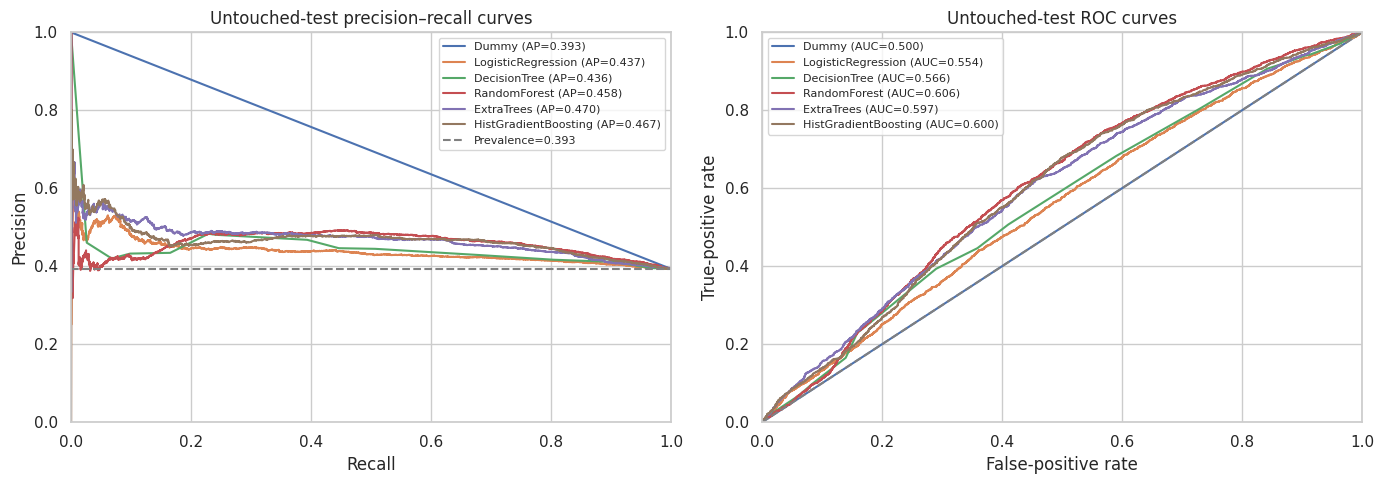

In [ ]:
def expected_calibration_error(y_true, probabilities, n_bins=10):
    y_array = np.asarray(y_true)
    p_array = np.asarray(probabilities)
    edges = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.clip(np.digitize(p_array, edges[1:-1], right=True), 0, n_bins - 1)
    ece = 0.0
    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        if mask.any():
            ece += mask.mean() * abs(y_array[mask].mean() - p_array[mask].mean())
    return float(ece)

def probability_scores(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return np.asarray(estimator.predict_proba(X))[:, 1]
    scores = np.asarray(estimator.decision_function(X))
    return 1 / (1 + np.exp(-scores))

def comprehensive_metrics(y_true, probabilities, threshold=0.5):
    y_array = np.asarray(y_true).astype(int)
    p_array = np.clip(np.asarray(probabilities).astype(float), 1e-8, 1 - 1e-8)
    predictions = (p_array >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_array, predictions, labels=[0, 1]).ravel()
    precision_curve, recall_curve, _ = precision_recall_curve(y_array, p_array)
    return {
        "threshold": float(threshold),
        "average_precision": average_precision_score(y_array, p_array),
        "trapezoidal_pr_auc": auc(recall_curve, precision_curve),
        "roc_auc": roc_auc_score(y_array, p_array),
        "brier_score": brier_score_loss(y_array, p_array),
        "log_loss": log_loss(y_array, p_array, labels=[0, 1]),
        "ece_10_bins": expected_calibration_error(y_array, p_array, 10),
        "accuracy": accuracy_score(y_array, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_array, predictions),
        "precision": precision_score(y_array, predictions, zero_division=0),
        "recall_sensitivity": recall_score(y_array, predictions, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "negative_predictive_value": tn / (tn + fn) if (tn + fn) else np.nan,
        "f1": f1_score(y_array, predictions, zero_division=0),
        "f2": fbeta_score(y_array, predictions, beta=2, zero_division=0),
        "matthews_correlation": matthews_corrcoef(y_array, predictions),
        "cohen_kappa": cohen_kappa_score(y_array, predictions),
        "true_negative": int(tn), "false_positive": int(fp),
        "false_negative": int(fn), "true_positive": int(tp),
    }

X_test_strict = data.loc[INDEX["test"], STRICT_FEATURES]
y_test = data.loc[INDEX["test"], "target"].to_numpy()

test_probabilities = {}
test_rows = []
for model_name, estimator in strict_models.items():
    probabilities = probability_scores(estimator, X_test_strict)
    test_probabilities[model_name] = probabilities
    row = {"model": model_name, **comprehensive_metrics(y_test, probabilities, threshold=0.5)}
    test_rows.append(row)
test_metrics_050 = pd.DataFrame(test_rows).sort_values("average_precision", ascending=False)
test_metrics_050.to_csv(TABLE_DIR / "all_models_test_metrics_threshold_050.csv", index=False)
display(test_metrics_050)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model_name, probabilities in test_probabilities.items():
    precision_values, recall_values, _ = precision_recall_curve(y_test, probabilities)
    axes[0].plot(recall_values, precision_values, label=f"{model_name} (AP={average_precision_score(y_test, probabilities):.3f})")
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    axes[1].plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc_score(y_test, probabilities):.3f})")
axes[0].axhline(y_test.mean(), color="grey", linestyle="--", label=f"Prevalence={y_test.mean():.3f}")
axes[0].set(title="Untouched-test precision–recall curves", xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1))
axes[1].plot([0, 1], [0, 1], color="grey", linestyle="--")
axes[1].set(title="Untouched-test ROC curves", xlabel="False-positive rate", ylabel="True-positive rate", xlim=(0, 1), ylim=(0, 1))
for axis in axes:
    axis.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "test_pr_roc_curves.png", dpi=180, bbox_inches="tight")
plt.show()

Selected operational model: LogisticRegression
Validation-selected F2 threshold: 0.035


,policy,threshold,average_precision,trapezoidal_pr_auc,roc_auc,brier_score,log_loss,ece_10_bins,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,negative_predictive_value,f1,f2,matthews_correlation,cohen_kappa,true_negative,false_positive,false_negative,true_positive
0,probability_threshold_0.50,0.5000,0.4375,0.4370,0.5538,0.2751,0.8010,0.1873,0.6073,0.5025,0.5490,0.0105,0.9944,0.6078,0.0206,0.0131,0.0277,0.0059,4091,23,2640,28
1,validation_selected_F2,0.0350,0.4375,0.4370,0.5538,0.2751,0.8010,0.1873,0.4040,0.5045,0.3956,0.9756,0.0333,0.6782,0.5629,0.7544,0.0257,0.0071,137,3977,65,2603


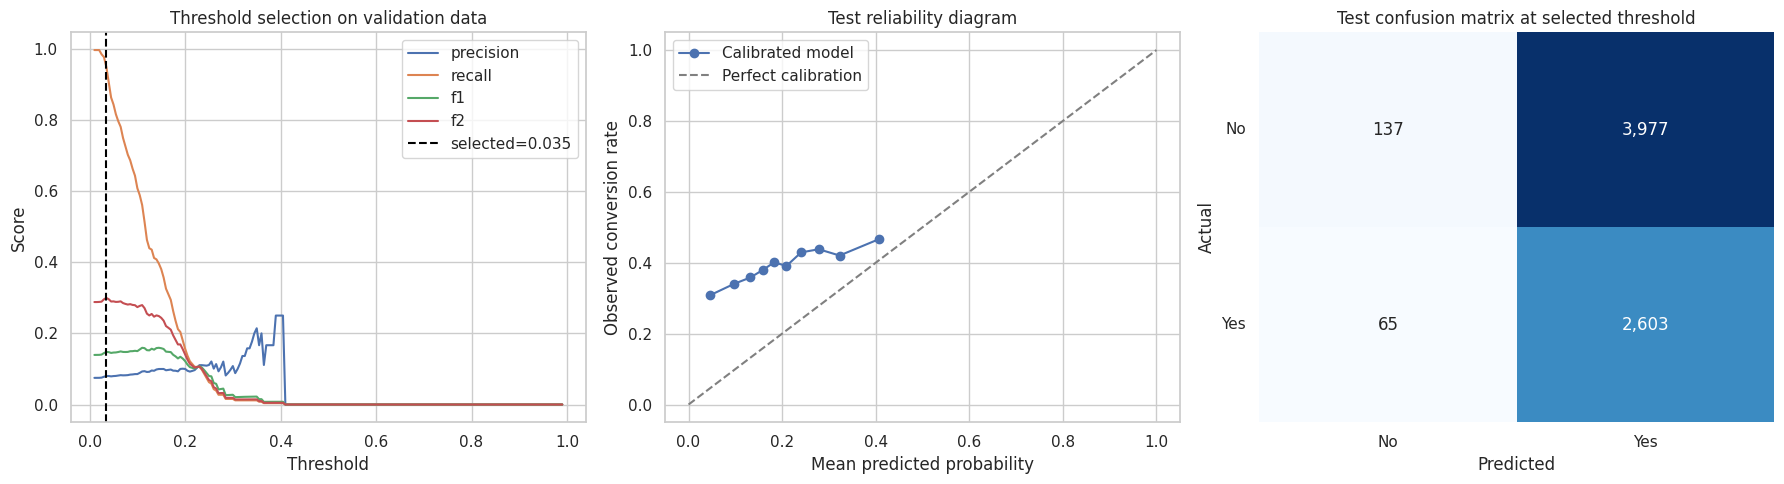

In [ ]:
best_operational_name = cv_leaderboard.loc[cv_leaderboard["model"] != "Dummy"].iloc[0]["model"]
best_operational_raw = strict_models[best_operational_name]
X_calibration = data.loc[INDEX["calibration"], STRICT_FEATURES]
y_calibration = data.loc[INDEX["calibration"], "target"]
X_threshold = data.loc[INDEX["threshold"], STRICT_FEATURES]
y_threshold = data.loc[INDEX["threshold"], "target"].to_numpy()

try:
    from sklearn.frozen import FrozenEstimator
    calibrated_model = CalibratedClassifierCV(FrozenEstimator(best_operational_raw), method="sigmoid")
except ImportError:
    calibrated_model = CalibratedClassifierCV(best_operational_raw, method="sigmoid", cv="prefit")
calibrated_model.fit(X_calibration, y_calibration)

threshold_probabilities = probability_scores(calibrated_model, X_threshold)
threshold_grid = np.linspace(0.01, 0.99, 197)
threshold_scores = pd.DataFrame({
    "threshold": threshold_grid,
    "f2": [fbeta_score(y_threshold, threshold_probabilities >= threshold, beta=2, zero_division=0) for threshold in threshold_grid],
    "f1": [f1_score(y_threshold, threshold_probabilities >= threshold, zero_division=0) for threshold in threshold_grid],
    "precision": [precision_score(y_threshold, threshold_probabilities >= threshold, zero_division=0) for threshold in threshold_grid],
    "recall": [recall_score(y_threshold, threshold_probabilities >= threshold, zero_division=0) for threshold in threshold_grid],
})
selected_threshold = float(threshold_scores.loc[threshold_scores["f2"].idxmax(), "threshold"])
threshold_scores.to_csv(TABLE_DIR / "validation_threshold_search.csv", index=False)

test_probabilities_calibrated = probability_scores(calibrated_model, X_test_strict)
detailed_metrics = pd.DataFrame([
    {"policy": "probability_threshold_0.50", **comprehensive_metrics(y_test, test_probabilities_calibrated, 0.5)},
    {"policy": "validation_selected_F2", **comprehensive_metrics(y_test, test_probabilities_calibrated, selected_threshold)},
])
detailed_metrics.to_csv(TABLE_DIR / "selected_model_detailed_test_metrics.csv", index=False)

print(f"Selected operational model: {best_operational_name}")
print(f"Validation-selected F2 threshold: {selected_threshold:.3f}")
display(detailed_metrics)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for metric in ["precision", "recall", "f1", "f2"]:
    axes[0].plot(threshold_scores["threshold"], threshold_scores[metric], label=metric)
axes[0].axvline(selected_threshold, color="black", linestyle="--", label=f"selected={selected_threshold:.3f}")
axes[0].set(title="Threshold selection on validation data", xlabel="Threshold", ylabel="Score")
axes[0].legend()

fraction_positive, mean_predicted = calibration_curve(y_test, test_probabilities_calibrated, n_bins=10, strategy="quantile")
axes[1].plot(mean_predicted, fraction_positive, marker="o", label="Calibrated model")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfect calibration")
axes[1].set(title="Test reliability diagram", xlabel="Mean predicted probability", ylabel="Observed conversion rate")
axes[1].legend()

selected_predictions = (test_probabilities_calibrated >= selected_threshold).astype(int)
cm = confusion_matrix(y_test, selected_predictions, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[2])
axes[2].set(title="Test confusion matrix at selected threshold", xlabel="Predicted", ylabel="Actual")
axes[2].set_xticklabels(["No", "Yes"])
axes[2].set_yticklabels(["No", "Yes"], rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "threshold_calibration_confusion.png", dpi=180, bbox_inches="tight")
plt.show()

In [ ]:
def stratified_bootstrap_indices(y_values, repetitions, seed=RANDOM_STATE):
    y_array = np.asarray(y_values)
    positive = np.flatnonzero(y_array == 1)
    negative = np.flatnonzero(y_array == 0)
    rng = np.random.default_rng(seed)
    for _ in range(repetitions):
        sampled = np.concatenate([
            rng.choice(positive, size=len(positive), replace=True),
            rng.choice(negative, size=len(negative), replace=True),
        ])
        rng.shuffle(sampled)
        yield sampled

def bootstrap_metric_intervals(y_values, probabilities, threshold, repetitions=BOOTSTRAP_REPETITIONS):
    collected = []
    for indices in stratified_bootstrap_indices(y_values, repetitions):
        collected.append(comprehensive_metrics(np.asarray(y_values)[indices], np.asarray(probabilities)[indices], threshold))
    bootstrap_frame = pd.DataFrame(collected)
    rows = []
    point = comprehensive_metrics(y_values, probabilities, threshold)
    for metric, estimate in point.items():
        if metric in bootstrap_frame.columns and metric != "threshold":
            rows.append({
                "metric": metric,
                "estimate": estimate,
                "ci_lower_95": bootstrap_frame[metric].quantile(0.025),
                "ci_upper_95": bootstrap_frame[metric].quantile(0.975),
            })
    return pd.DataFrame(rows), bootstrap_frame

winner_intervals, winner_bootstrap = bootstrap_metric_intervals(
    y_test, test_probabilities_calibrated, selected_threshold
)
winner_intervals.to_csv(TABLE_DIR / "selected_model_bootstrap_confidence_intervals.csv", index=False)
display(winner_intervals)

,metric,estimate,ci_lower_95,ci_upper_95
0,average_precision,0.4375,0.4240,0.4532
1,trapezoidal_pr_auc,0.4370,0.4233,0.4523
2,roc_auc,0.5538,0.5388,0.5689
3,brier_score,0.2751,0.2722,0.2778
4,log_loss,0.8010,0.7905,0.8110
5,ece_10_bins,0.1873,0.1848,0.1905
6,accuracy,0.4040,0.4003,0.4081
7,balanced_accuracy,0.5045,0.5008,0.5082
8,precision,0.3956,0.3938,0.3975
9,recall_sensitivity,0.9756,0.9696,0.9816


,top_fraction,customers_contacted,observed_conversions,conversion_rate_precision_at_k,recall_gain_at_k,lift,expected_conversions_from_probabilities,random_expected_conversions,additional_observed_vs_random_expectation
0,0.0500,340,176,0.5176,0.0660,1.3158,153.9673,133.7541,42.2459
1,0.1000,679,317,0.4669,0.1188,1.1868,276.7543,267.1147,49.8853
2,0.2000,1357,602,0.4436,0.2256,1.1277,495.5987,533.8360,68.1640


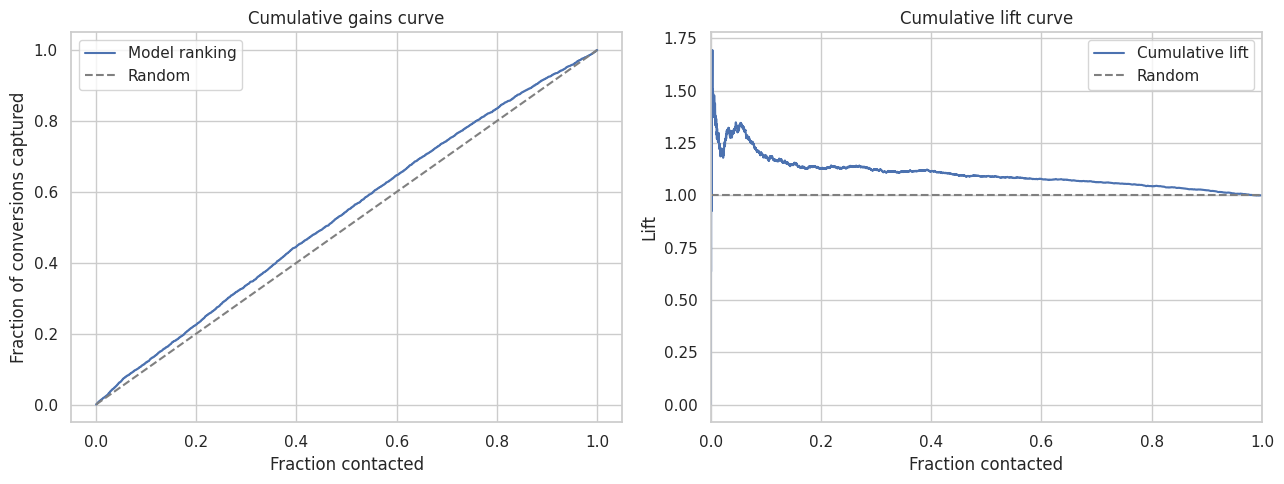

In [ ]:
def prioritisation_table(y_values, probabilities, fractions=(0.05, 0.10, 0.20)):
    y_array = np.asarray(y_values)
    p_array = np.asarray(probabilities)
    order = np.argsort(-p_array)
    prevalence = y_array.mean()
    rows = []
    for fraction in fractions:
        k = max(1, int(np.ceil(len(y_array) * fraction)))
        selected = order[:k]
        conversions = int(y_array[selected].sum())
        conversion_rate = conversions / k
        rows.append({
            "top_fraction": fraction,
            "customers_contacted": k,
            "observed_conversions": conversions,
            "conversion_rate_precision_at_k": conversion_rate,
            "recall_gain_at_k": conversions / y_array.sum(),
            "lift": conversion_rate / prevalence,
            "expected_conversions_from_probabilities": float(p_array[selected].sum()),
            "random_expected_conversions": float(k * prevalence),
            "additional_observed_vs_random_expectation": float(conversions - k * prevalence),
        })
    return pd.DataFrame(rows)

prioritisation = prioritisation_table(y_test, test_probabilities_calibrated)
prioritisation.to_csv(TABLE_DIR / "campaign_prioritisation.csv", index=False)
display(prioritisation)

sorted_order = np.argsort(-test_probabilities_calibrated)
sorted_y = y_test[sorted_order]
population_fraction = np.arange(1, len(y_test) + 1) / len(y_test)
cumulative_gain = np.cumsum(sorted_y) / sorted_y.sum()
cumulative_lift = cumulative_gain / population_fraction

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(population_fraction, cumulative_gain, label="Model ranking")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random")
axes[0].set(title="Cumulative gains curve", xlabel="Fraction contacted", ylabel="Fraction of conversions captured")
axes[0].legend()
axes[1].plot(population_fraction, cumulative_lift, label="Cumulative lift")
axes[1].axhline(1, linestyle="--", color="grey", label="Random")
axes[1].set(title="Cumulative lift curve", xlabel="Fraction contacted", ylabel="Lift", xlim=(0, 1))
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "gains_and_lift.png", dpi=180, bbox_inches="tight")
plt.show()

,feature_set,cv_average_precision,average_precision,roc_auc,brier_score,ece_10_bins
0,no_duration,0.0843,0.4679,0.6028,0.2495,0.1327
1,with_duration,0.4690,0.5507,0.6947,0.2711,0.2258


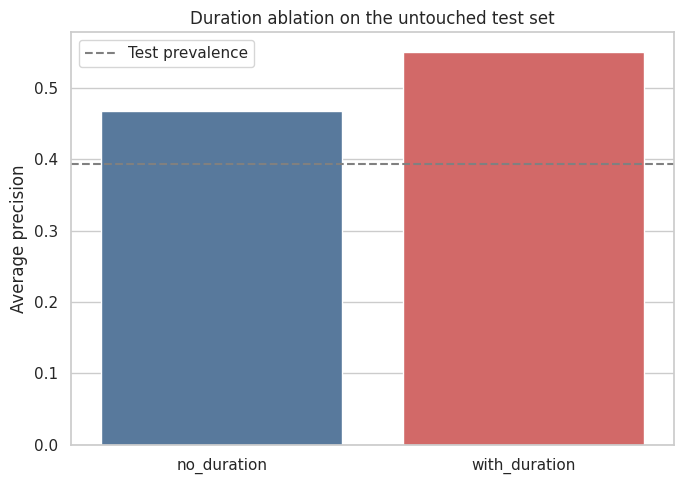

In [ ]:
ENSEMBLES = ["RandomForest", "ExtraTrees", "HistGradientBoosting"]
available_ensembles = cv_leaderboard[cv_leaderboard["model"].isin(ENSEMBLES)]
best_ensemble_name = available_ensembles.iloc[0]["model"]

def tune_single_model(model_name, features, label, iterations=ABLATION_ITERATIONS):
    X_dev = data.loc[INDEX["train"], features].reset_index(drop=True)
    y_dev = data.loc[INDEX["train"], "target"].reset_index(drop=True)
    pipeline, space = model_and_space(model_name, data, features)
    search = RandomizedSearchCV(
        pipeline, space, n_iter=iterations, scoring=SCORING, refit="average_precision",
        cv=temporal_cv, random_state=RANDOM_STATE, n_jobs=N_JOBS,
        return_train_score=True, error_score=np.nan
    )
    with mlflow.start_run(run_name=f"ablation_{label}_{model_name}"):
        mlflow.set_tags({"feature_set": label, "hypothesis": "H2"})
        search.fit(X_dev, y_dev)
        mlflow.log_metric("best_cv_average_precision", float(search.best_score_))
        mlflow.log_dict(search.best_params_, "best_parameters.json")
    pd.DataFrame(search.cv_results_).to_csv(TABLE_DIR / f"cv_ablation_{label}.csv", index=False)
    return search.best_estimator_, float(search.best_score_)

no_duration_model, no_duration_cv_ap = tune_single_model(best_ensemble_name, NO_DURATION_FEATURES, "no_duration")
full_duration_model, full_duration_cv_ap = tune_single_model(best_ensemble_name, FULL_FEATURES, "with_duration")

no_duration_test_prob = probability_scores(no_duration_model, data.loc[INDEX["test"], NO_DURATION_FEATURES])
full_duration_test_prob = probability_scores(full_duration_model, data.loc[INDEX["test"], FULL_FEATURES])

duration_ablation = pd.DataFrame([
    {"feature_set": "no_duration", "cv_average_precision": no_duration_cv_ap, **comprehensive_metrics(y_test, no_duration_test_prob, 0.5)},
    {"feature_set": "with_duration", "cv_average_precision": full_duration_cv_ap, **comprehensive_metrics(y_test, full_duration_test_prob, 0.5)},
])
duration_ablation.to_csv(TABLE_DIR / "duration_ablation.csv", index=False)
display(duration_ablation[["feature_set", "cv_average_precision", "average_precision", "roc_auc", "brier_score", "ece_10_bins"]])

plt.figure(figsize=(7, 5))
sns.barplot(data=duration_ablation, x="feature_set", y="average_precision", palette=["#4C78A8", "#E45756"])
plt.axhline(y_test.mean(), linestyle="--", color="grey", label="Test prevalence")
plt.title("Duration ablation on the untouched test set")
plt.xlabel("")
plt.ylabel("Average precision")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "duration_ablation.png", dpi=180, bbox_inches="tight")
plt.show()

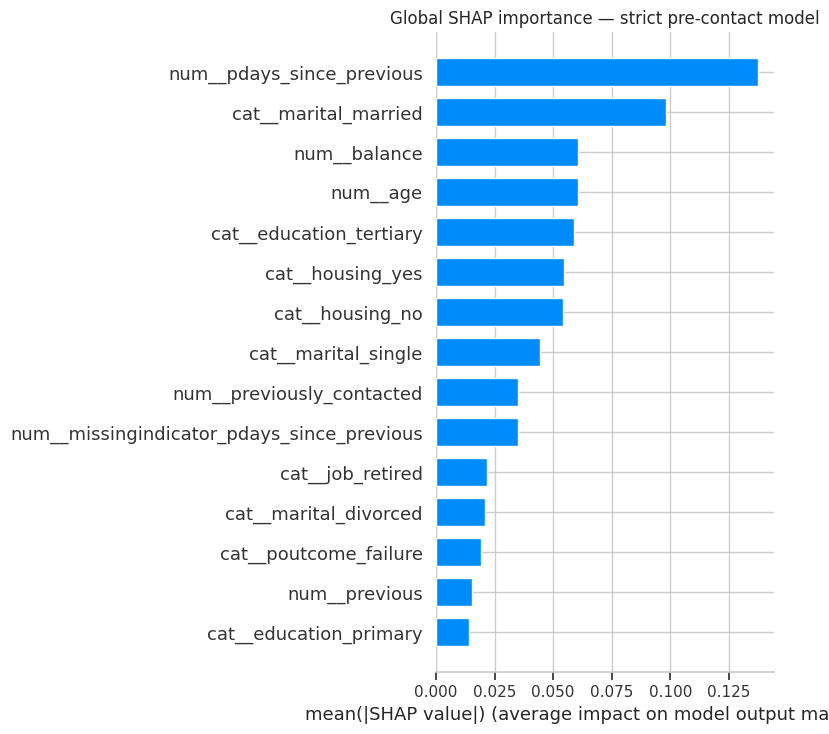

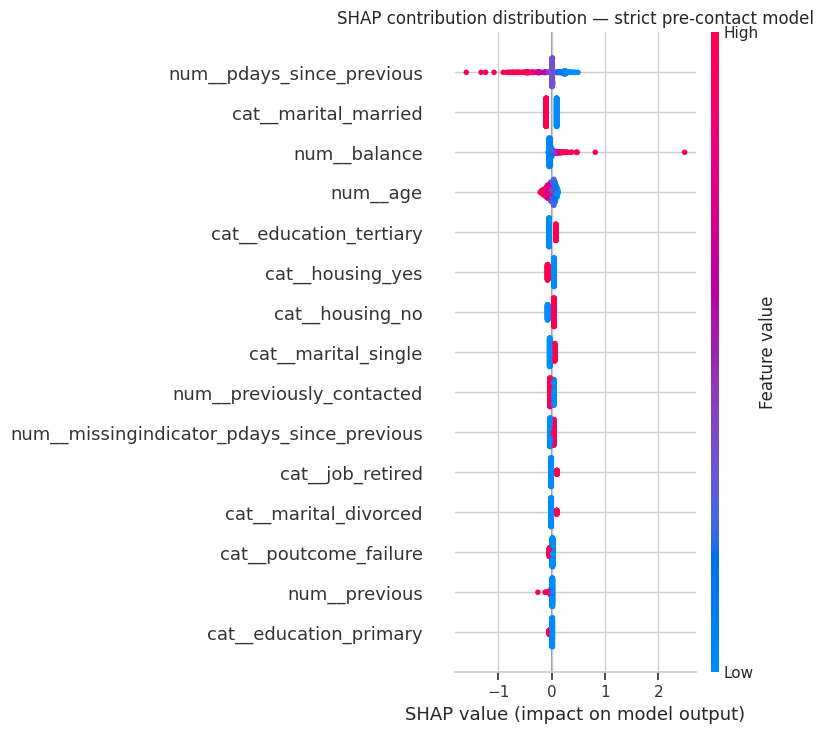

<Figure size 700x500 with 0 Axes>

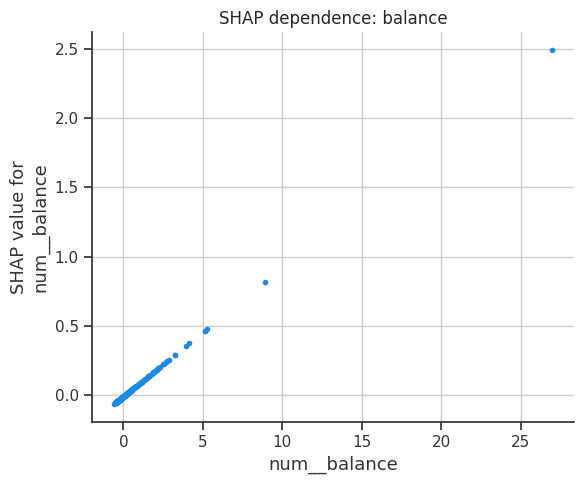

<Figure size 700x500 with 0 Axes>

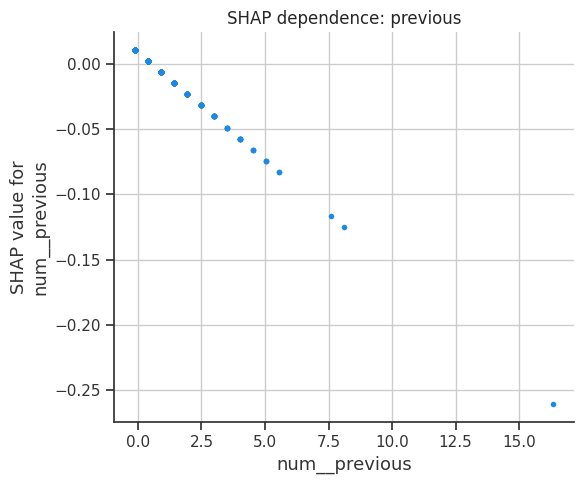

<Figure size 700x500 with 0 Axes>

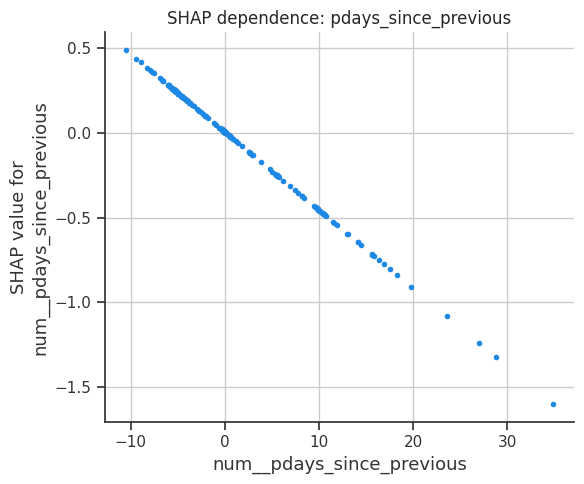

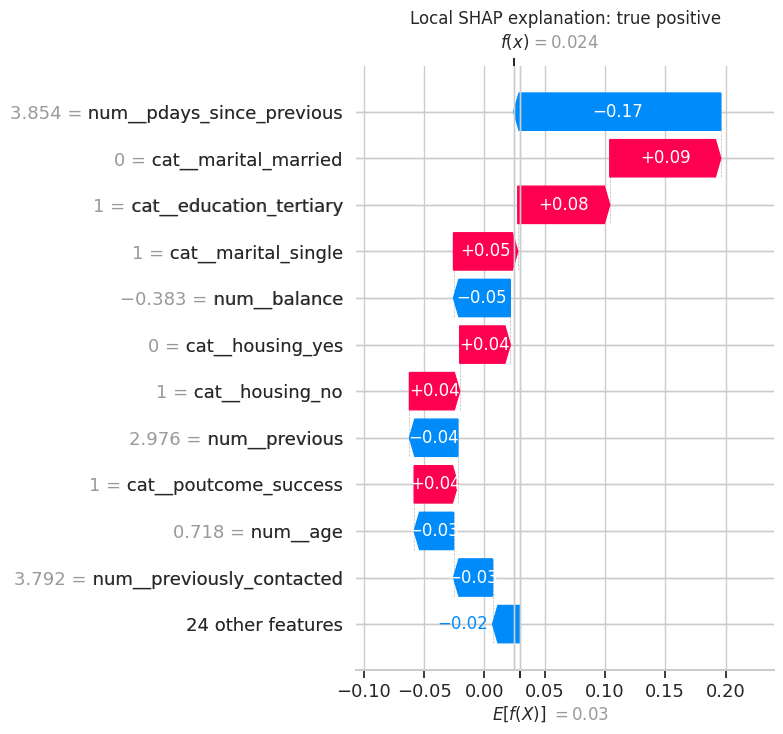

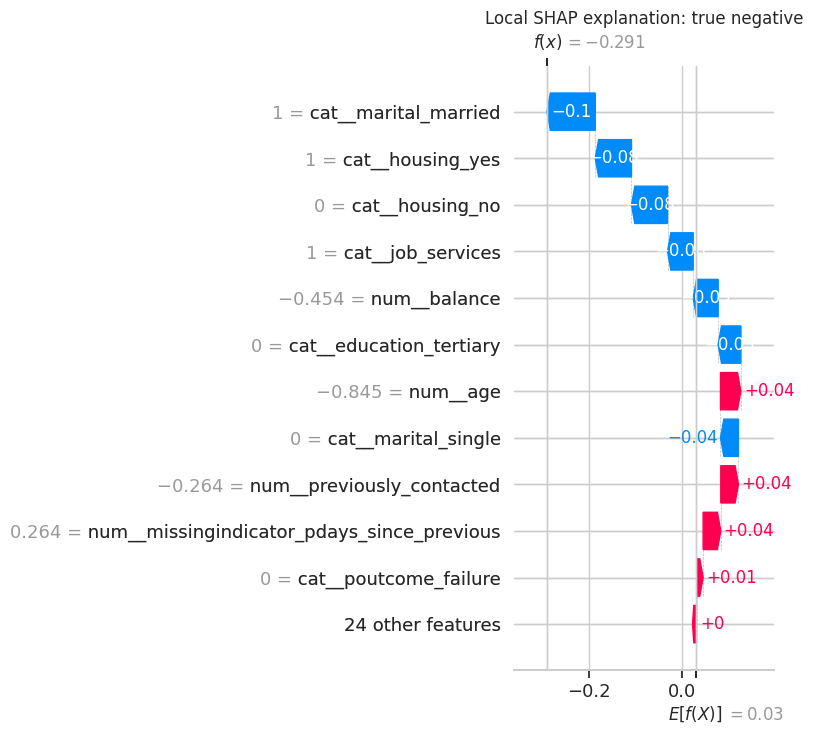

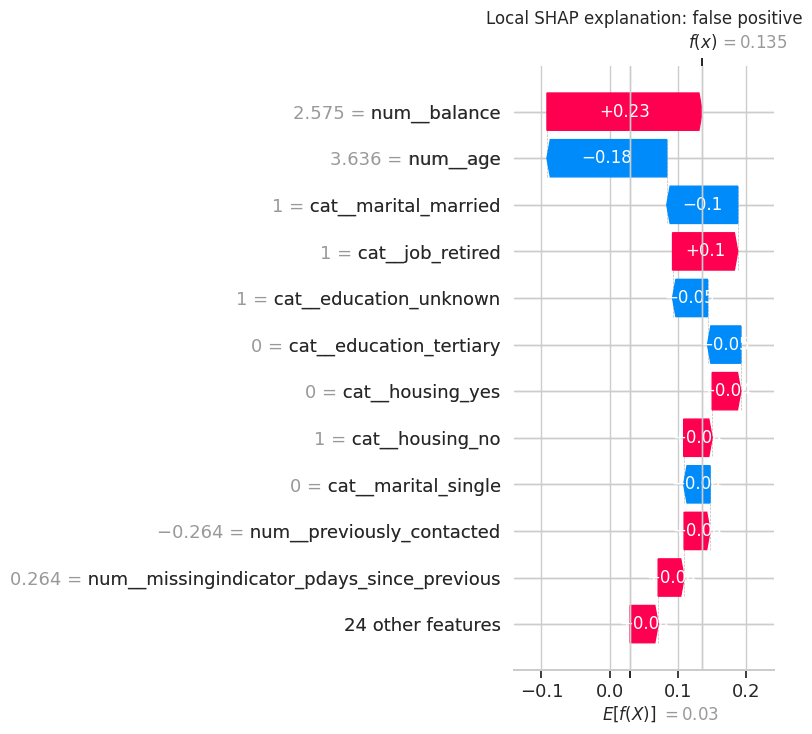

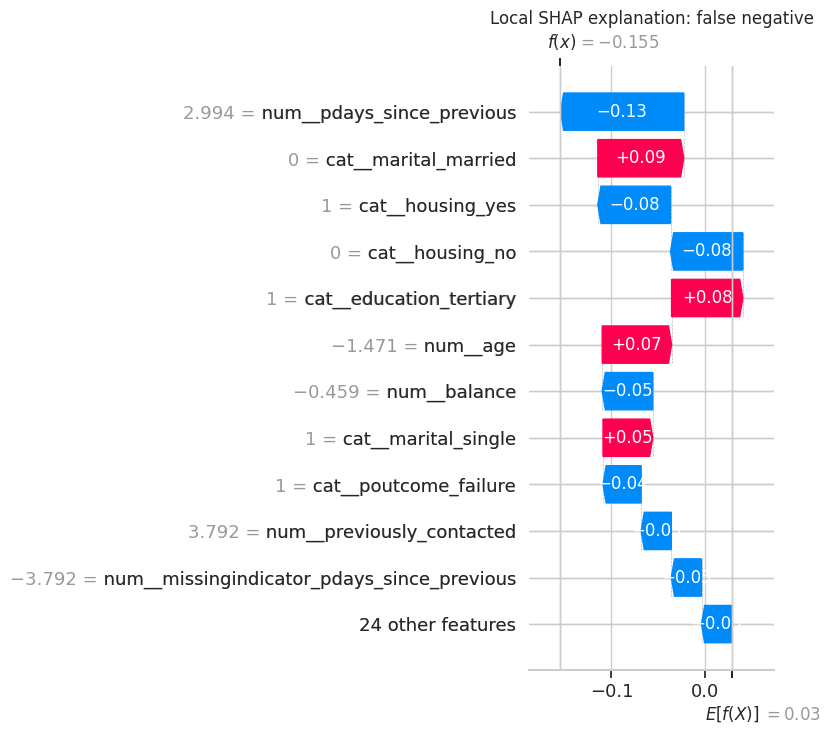

,original_feature,mean_abs_shap
8,pdays_since_previous,0.1723
7,marital,0.1631
4,housing,0.1087
3,education,0.0877
5,job,0.0635
1,balance,0.0608
0,age,0.0605
9,poutcome,0.0358
11,previously_contacted,0.0350
6,loan,0.0178


,feature,permutation_ap_decrease_mean,permutation_ap_decrease_sd
6,housing,0.0185,0.0021
11,poutcome,0.0113,0.0007
10,pdays_since_previous,0.0093,0.0018
5,balance,0.0061,0.0023
3,education,0.0045,0.0014
7,loan,0.0027,0.0008
2,marital,0.0026,0.0016
1,job,0.0009,0.0014
4,default,0.0000,0.0000
0,age,-0.0018,0.0014


In [ ]:
from scipy import sparse

def normalise_shap_values(explanation):
    values = np.asarray(explanation.values)
    if values.ndim == 3:
        values = values[:, :, 1]
    elif values.ndim != 2:
        raise ValueError(f"Unexpected SHAP shape: {values.shape}")
    return values

def encoded_to_original(encoded_name, raw_features):
    stripped = encoded_name.split("__", 1)[-1]
    if stripped.startswith("missingindicator_"):
        stripped = stripped.replace("missingindicator_", "", 1)
    for feature in sorted(raw_features, key=len, reverse=True):
        if stripped == feature or stripped.startswith(feature + "_"):
            return feature
    return stripped

def calculate_shap(estimator, X_raw, raw_features, sample_size=SHAP_SAMPLE_SIZE, make_plots=False, prefix="operational"):
    sample = X_raw.sample(min(sample_size, len(X_raw)), random_state=RANDOM_STATE)
    preprocessor = estimator.named_steps["preprocess"]
    fitted_model = estimator.named_steps["model"]
    transformed = preprocessor.transform(sample)
    if sparse.issparse(transformed):
        transformed = transformed.toarray()
    transformed = np.asarray(transformed)
    feature_names = np.asarray(preprocessor.get_feature_names_out(), dtype=str)

    if isinstance(fitted_model, LogisticRegression):
        background = transformed[: min(200, len(transformed))]
        explainer = shap.LinearExplainer(fitted_model, background)
        explanation = explainer(transformed)
    else:
        explainer = shap.TreeExplainer(fitted_model)
        explanation = explainer(transformed)
    values = normalise_shap_values(explanation)
    base_values = np.asarray(explanation.base_values)
    if base_values.ndim == 0:
        row_base_values = np.repeat(float(base_values), len(transformed))
    elif base_values.ndim == 1:
        if len(base_values) == len(transformed):
            row_base_values = base_values
        elif len(base_values) > 1:
            row_base_values = np.repeat(float(base_values[1]), len(transformed))
        else:
            row_base_values = np.repeat(float(base_values[0]), len(transformed))
    else:
        row_base_values = base_values[:, 1] if base_values.shape[1] > 1 else base_values[:, 0]

    encoded_importance = pd.DataFrame({
        "encoded_feature": feature_names,
        "mean_abs_shap": np.abs(values).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)
    encoded_importance["original_feature"] = encoded_importance["encoded_feature"].map(
        lambda name: encoded_to_original(name, raw_features)
    )
    grouped = encoded_importance.groupby("original_feature", as_index=False)["mean_abs_shap"].sum().sort_values("mean_abs_shap", ascending=False)

    if make_plots:
        plt.figure(figsize=(9, 6))
        shap.summary_plot(values, transformed, feature_names=feature_names, plot_type="bar", max_display=15, show=False)
        plt.title("Global SHAP importance — strict pre-contact model")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / f"{prefix}_shap_bar.png", dpi=180, bbox_inches="tight")
        plt.show()

        plt.figure(figsize=(9, 7))
        shap.summary_plot(values, transformed, feature_names=feature_names, max_display=15, show=False)
        plt.title("SHAP contribution distribution — strict pre-contact model")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / f"{prefix}_shap_beeswarm.png", dpi=180, bbox_inches="tight")
        plt.show()

        for raw_feature in ["balance", "previous", "pdays_since_previous"]:
            candidates = [
                index for index, encoded_name in enumerate(feature_names)
                if encoded_to_original(encoded_name, raw_features) == raw_feature
                and "missingindicator" not in encoded_name
            ]
            if candidates:
                plt.figure(figsize=(7, 5))
                shap.dependence_plot(
                    candidates[0], values, transformed, feature_names=feature_names,
                    interaction_index=None, show=False
                )
                plt.title(f"SHAP dependence: {raw_feature}")
                plt.tight_layout()
                plt.savefig(FIGURE_DIR / f"{prefix}_shap_dependence_{raw_feature}.png", dpi=180, bbox_inches="tight")
                plt.show()

        actual = data.loc[sample.index, "target"].to_numpy()
        raw_predictions = (probability_scores(estimator, sample) >= 0.5).astype(int)
        case_masks = {
            "true_positive": (actual == 1) & (raw_predictions == 1),
            "true_negative": (actual == 0) & (raw_predictions == 0),
            "false_positive": (actual == 0) & (raw_predictions == 1),
            "false_negative": (actual == 1) & (raw_predictions == 0),
        }
        for case_name, case_mask in case_masks.items():
            positions = np.flatnonzero(case_mask)
            if len(positions) == 0:
                continue
            position = int(positions[0])
            local_explanation = shap.Explanation(
                values=values[position],
                base_values=row_base_values[position],
                data=transformed[position],
                feature_names=feature_names,
            )
            plt.figure(figsize=(9, 6))
            shap.plots.waterfall(local_explanation, max_display=12, show=False)
            plt.title(f"Local SHAP explanation: {case_name.replace('_', ' ')}")
            plt.tight_layout()
            plt.savefig(FIGURE_DIR / f"{prefix}_shap_waterfall_{case_name}.png", dpi=180, bbox_inches="tight")
            plt.show()
    return encoded_importance, grouped

encoded_shap, grouped_shap = calculate_shap(
    best_operational_raw, X_test_strict, STRICT_FEATURES, make_plots=True, prefix="operational"
)
encoded_shap.to_csv(TABLE_DIR / "shap_encoded_importance.csv", index=False)
grouped_shap.to_csv(TABLE_DIR / "shap_grouped_importance.csv", index=False)

permutation = permutation_importance(
    best_operational_raw, X_test_strict, y_test, scoring="average_precision",
    n_repeats=10 if FAST_MODE else 30, random_state=RANDOM_STATE, n_jobs=N_JOBS
)
permutation_table = pd.DataFrame({
    "feature": STRICT_FEATURES,
    "permutation_ap_decrease_mean": permutation.importances_mean,
    "permutation_ap_decrease_sd": permutation.importances_std,
}).sort_values("permutation_ap_decrease_mean", ascending=False)
permutation_table.to_csv(TABLE_DIR / "permutation_importance.csv", index=False)

display(grouped_shap.head(15))
display(permutation_table.head(15))

full_encoded_shap, full_grouped_shap = calculate_shap(
    full_duration_model, data.loc[INDEX["test"], FULL_FEATURES], FULL_FEATURES,
    sample_size=min(300, SHAP_SAMPLE_SIZE), make_plots=False, prefix="full"
)
full_grouped_shap.to_csv(TABLE_DIR / "full_model_shap_grouped_importance.csv", index=False)
duration_rows = full_grouped_shap.reset_index(drop=True)
duration_matches = duration_rows.index[duration_rows["original_feature"] == "duration"].tolist()
duration_shap_rank = int(duration_matches[0] + 1) if duration_matches else np.nan

Tuning LogisticRegression with SMOTE...
Tuning RandomForest with SMOTE...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=8. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Tuning HistGradientBoosting with SMOTE...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=8. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,Model,Best_CV_F1
0,LogisticRegression,0.1399
1,RandomForest,0.0074
2,HistGradientBoosting,0.0015



Test performance for LogisticRegression with SMOTE (Threshold 0.5):


,accuracy,precision,recall_sensitivity,f1,roc_auc,average_precision
0,0.5274,0.4316,0.6353,0.5140,0.5615,0.4464


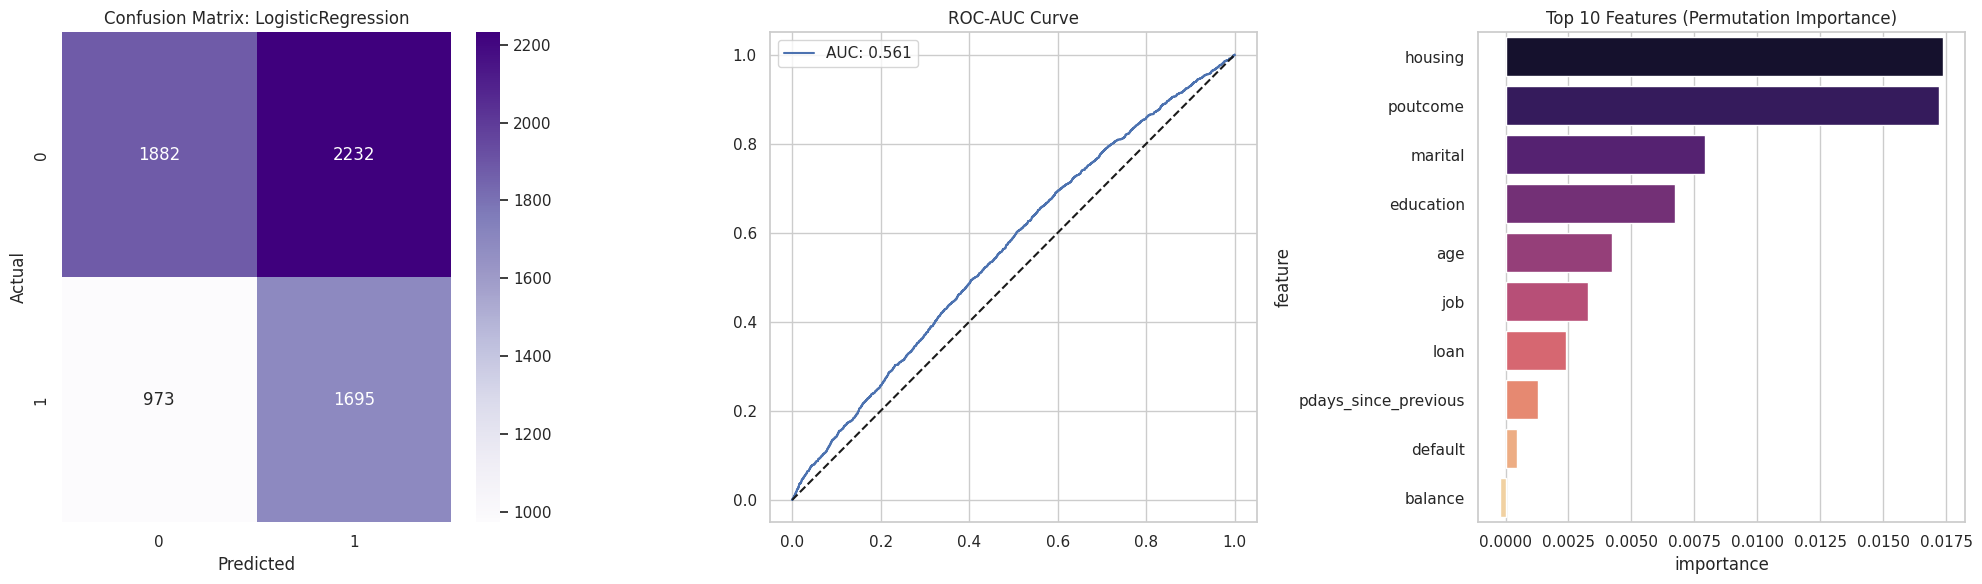

In [ ]:
!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

def fit_smote_candidates(features, search_iterations=SEARCH_ITERATIONS):
    X_dev = data.loc[INDEX['train'], features].reset_index(drop=True)
    y_dev = data.loc[INDEX['train'], 'target'].reset_index(drop=True)

    fitted = {}
    leaderboard = []

    # Selected models for evaluation
    models_to_run = ["LogisticRegression", "RandomForest", "HistGradientBoosting"]

    for name in models_to_run:
        print(f"Tuning {name} with SMOTE...")

        # Re-use your existing preprocessor logic
        dense = (name == "HistGradientBoosting")
        scale = (name == "LogisticRegression")
        preprocessor = make_preprocessor(data, features, dense=dense, scale_numeric=scale)

        # Define base model
        if name == "LogisticRegression":
            model = LogisticRegression(max_iter=2500, solver="liblinear", random_state=RANDOM_STATE)
            params = {"model__C": np.logspace(-3, 2, 8)}
        elif name == "RandomForest":
            model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)
            params = {"model__n_estimators": [100, 200], "model__max_depth": [5, 10, 20]}
        elif name == "HistGradientBoosting":
            model = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
            params = {"model__max_iter": [100, 150], "model__learning_rate": [0.05, 0.1]}

        # Pipeline: Preprocess -> SMOTE -> Model
        # SMOTE is only applied to the training data in each CV fold
        pipeline = ImbPipeline([
            ("preprocess", preprocessor),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("model", model)
        ])

        # Randomized Search focusing on F1-score
        search = RandomizedSearchCV(
            pipeline, params, n_iter=search_iterations, scoring='f1',
            cv=temporal_cv, random_state=RANDOM_STATE, n_jobs=N_JOBS
        )
        search.fit(X_dev, y_dev)

        fitted[name] = search.best_estimator_
        leaderboard.append({
            "Model": name,
            "Best_CV_F1": search.best_score_,
        })

    return fitted, pd.DataFrame(leaderboard).sort_values("Best_CV_F1", ascending=False)

# 1. Train models
smote_models, smote_leaderboard = fit_smote_candidates(STRICT_FEATURES)
display(smote_leaderboard)

# 2. Evaluate on Test Set
best_smote_name = smote_leaderboard.iloc[0]["Model"]
best_smote_model = smote_models[best_smote_name]
best_probs = probability_scores(best_smote_model, X_test_strict)

# 3. Comprehensive Metrics
final_metrics = comprehensive_metrics(y_test, best_probs, threshold=0.5)
print(f"\nTest performance for {best_smote_name} with SMOTE (Threshold 0.5):")
display(pd.DataFrame([final_metrics])[["accuracy", "precision", "recall_sensitivity", "f1", "roc_auc", "average_precision"]])

# 4. Visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Confusion Matrix
cm_smote = confusion_matrix(y_test, best_probs >= 0.5)
sns.heatmap(cm_smote, annot=True, fmt="d", cmap="Purples", ax=axes[0])
axes[0].set_title(f"Confusion Matrix: {best_smote_name}")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ROC Curve
fpr_s, tpr_s, _ = roc_curve(y_test, best_probs)
axes[1].plot(fpr_s, tpr_s, label=f"AUC: {auc(fpr_s, tpr_s):.3f}")
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title("ROC-AUC Curve")
axes[1].legend()

# Permutation Feature Importance
perm_smote = permutation_importance(best_smote_model, X_test_strict, y_test, n_repeats=5, random_state=RANDOM_STATE)
imp_df = pd.DataFrame({"feature": STRICT_FEATURES, "importance": perm_smote.importances_mean}).sort_values("importance", ascending=False)
sns.barplot(x="importance", y="feature", data=imp_df.head(10), ax=axes[2], palette="magma")
axes[2].set_title("Top 10 Features (Permutation Importance)")

plt.tight_layout()
plt.show()

## 10. Advanced, leakage-safe F1 improvement experiments

In [ ]:
# Extra estimators used only by the advanced experiments.
!pip install -q catboost xgboost

In [ ]:
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from sklearn.model_selection import StratifiedKFold

ADVANCED_FAST_MODE = bool(FAST_MODE)
ADVANCED_SEARCH_ITERATIONS = 3 if ADVANCED_FAST_MODE else 15
ADVANCED_CV_SPLITS = 3 if ADVANCED_FAST_MODE else 5

def select_f1_threshold(y_true, probabilities):
    """Utility to find the threshold that maximizes binary F1 score."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, probabilities)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = float(thresholds[best_idx]) if best_idx < len(thresholds) else 0.5

    threshold_table = pd.DataFrame({
        "threshold": thresholds,
        "precision": precisions[:-1],
        "recall": recalls[:-1],
        "f1": f1_scores[:-1]
    })
    return best_threshold, threshold_table

advanced_required_objects = [
    "data", "INDEX", "STRICT_FEATURES", "NO_DURATION_FEATURES",
    "FULL_FEATURES", "column_types", "make_preprocessor",
    "valid_time_series_cv", "probability_scores",
    "comprehensive_metrics", "select_f1_threshold", "TABLE_DIR",
    "FIGURE_DIR",
]
advanced_missing_objects = [
    name for name in advanced_required_objects if name not in globals()
]
if advanced_missing_objects:
    raise RuntimeError(
        "Run every preceding notebook cell first. Missing objects: "
        + ", ".join(advanced_missing_objects)
    )

def unique_in_order(values):
    return list(dict.fromkeys(values))


def advanced_column_types(frame, features):
    # Recognise both traditional object columns and pandas StringDtype.
    categorical = []
    for column in features:
        dtype = frame[column].dtype
        if (
            pd.api.types.is_object_dtype(dtype)
            or pd.api.types.is_string_dtype(dtype)
            or isinstance(dtype, pd.CategoricalDtype)
        ):
            categorical.append(column)
    numerical = [column for column in features if column not in categorical]
    return numerical, categorical


def make_advanced_preprocessor(
    frame, features, dense=False, scale_numeric=False
):
    numerical, categorical = advanced_column_types(frame, features)
    numeric_steps = [(
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True,
            keep_empty_features=True,
        ),
    )]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(numeric_steps), numerical),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=not dense,
                        ),
                    ),
                ]),
                categorical,
            ),
        ],
        remainder="drop",
        sparse_threshold=0.0 if dense else 0.3,
        verbose_feature_names_out=True,
    )


def engineer_advanced_features(frame):
    # Create only deterministic row-level features; no target statistics are used.
    engineered = frame.copy()
    engineered["previous_campaign_success"] = (
        engineered["poutcome"].astype(str).str.lower() == "success"
    ).astype(int)
    engineered["balance_signed_log"] = (
        np.sign(engineered["balance"])
        * np.log1p(np.abs(pd.to_numeric(engineered["balance"], errors="coerce")))
    )
    engineered["previous_log"] = np.log1p(
        pd.to_numeric(engineered["previous"], errors="coerce").clip(lower=0)
    )
    engineered["pdays_log"] = np.log1p(
        pd.to_numeric(
            engineered["pdays_since_previous"], errors="coerce"
        ).clip(lower=0)
    )
    engineered["age_band"] = pd.cut(
        pd.to_numeric(engineered["age"], errors="coerce"),
        bins=[0, 24, 34, 44, 54, 64, np.inf],
        labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65+"],
        include_lowest=True,
    ).astype("object")

    engineered["contact_intensity"] = (
        pd.to_numeric(engineered["campaign"], errors="coerce").fillna(0)
        + pd.to_numeric(engineered["previous"], errors="coerce").fillna(0)
    )
    engineered["campaign_log"] = np.log1p(
        pd.to_numeric(engineered["campaign"], errors="coerce").clip(lower=0)
    )

    month_number = {
        "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
        "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12,
    }
    month_value = (
        engineered["month"].astype(str).str.lower().map(month_number).astype(float)
    )
    engineered["month_sin"] = np.sin(2 * np.pi * (month_value - 1) / 12)
    engineered["month_cos"] = np.cos(2 * np.pi * (month_value - 1) / 12)
    day_value = pd.to_numeric(engineered["day"], errors="coerce")
    engineered["day_sin"] = np.sin(2 * np.pi * (day_value - 1) / 31)
    engineered["day_cos"] = np.cos(2 * np.pi * (day_value - 1) / 31)

    duration_value = pd.to_numeric(engineered["duration"], errors="coerce")
    campaign_value = pd.to_numeric(
        engineered["campaign"], errors="coerce"
    ).clip(lower=1)
    engineered["duration_log"] = np.log1p(duration_value.clip(lower=0))
    engineered["duration_per_contact"] = duration_value / campaign_value

    categorical_columns = engineered.select_dtypes(
        include=["object", "category", "string"]
    ).columns
    for column in categorical_columns:
        engineered[column] = (
            engineered[column].astype("string").fillna("missing").astype(str)
        )
    return engineered


advanced_data = engineer_advanced_features(data)

ADVANCED_STRICT_FEATURES = unique_in_order(STRICT_FEATURES + [
    "previous_campaign_success", "balance_signed_log", "previous_log",
    "pdays_log", "age_band",
])
ADVANCED_NO_DURATION_FEATURES = unique_in_order(NO_DURATION_FEATURES + [
    "previous_campaign_success", "balance_signed_log", "previous_log",
    "pdays_log", "age_band", "contact_intensity", "campaign_log",
    "month_sin", "month_cos", "day_sin", "day_cos",
])
ADVANCED_FULL_FEATURES = unique_in_order(ADVANCED_NO_DURATION_FEATURES + [
    "duration", "duration_log", "duration_per_contact",
])

ADVANCED_FEATURE_SETS = {
    "Strict pre-contact (operational)": ADVANCED_STRICT_FEATURES,
    "Campaign data, no duration": ADVANCED_NO_DURATION_FEATURES,
    "Post-call benchmark with duration": ADVANCED_FULL_FEATURES,
}

advanced_feature_manifest = pd.DataFrame([
    {
        "feature_set": feature_set,
        "n_features": len(features),
        "features": ", ".join(features),
        "operational_interpretation": (
            "pre-contact operational"
            if feature_set.startswith("Strict")
            else "current-campaign, before outcome"
            if feature_set.startswith("Campaign")
            else "post-call benchmark; not valid for pre-call targeting"
        ),
    }
    for feature_set, features in ADVANCED_FEATURE_SETS.items()
])
advanced_feature_manifest.to_csv(
    TABLE_DIR / "advanced_feature_manifest.csv", index=False
)
display(advanced_feature_manifest)

,feature_set,n_features,features,operational_interpretation
0,Strict pre-contact (operational),17,"age, job, marital, education, default, balance...",pre-contact operational
1,"Campaign data, no duration",27,"age, job, marital, education, default, balance...","current-campaign, before outcome"
2,Post-call benchmark with duration,30,"age, job, marital, education, default, balance...",post-call benchmark; not valid for pre-call ta...


In [ ]:
# Create a stratified-random benchmark with the same 70/7.5/7.5/15
# train/calibration/threshold/test proportions as the temporal design.
all_advanced_indices = np.arange(len(advanced_data))
random_development_indices, random_test_indices = train_test_split(
    all_advanced_indices,
    test_size=0.15,
    stratify=advanced_data["target"],
    random_state=RANDOM_STATE,
)
random_train_indices, random_calibration_threshold_indices = train_test_split(
    random_development_indices,
    test_size=15 / 85,
    stratify=advanced_data.loc[random_development_indices, "target"],
    random_state=RANDOM_STATE,
)
random_calibration_indices, random_threshold_indices = train_test_split(
    random_calibration_threshold_indices,
    test_size=0.50,
    stratify=advanced_data.loc[
        random_calibration_threshold_indices, "target"
    ],
    random_state=RANDOM_STATE,
)

RANDOM_INDEX = {
    "train": np.asarray(random_train_indices),
    "calibration": np.asarray(random_calibration_indices),
    "threshold": np.asarray(random_threshold_indices),
    "test": np.asarray(random_test_indices),
}
ADVANCED_SCENARIOS = {
    "Temporal realistic": {"indices": INDEX, "cv_kind": "temporal"},
    "Stratified random benchmark": {
        "indices": RANDOM_INDEX,
        "cv_kind": "stratified",
    },
}


def advanced_cv_for_scenario(scenario_name, y_train_values):
    if ADVANCED_SCENARIOS[scenario_name]["cv_kind"] == "temporal":
        return valid_time_series_cv(
            pd.Series(y_train_values).reset_index(drop=True),
            ADVANCED_CV_SPLITS,
        )
    return StratifiedKFold(
        n_splits=ADVANCED_CV_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )


advanced_split_summary = pd.DataFrame([
    {
        "evaluation": scenario_name,
        "split": split_name,
        "rows": len(split_indices),
        "positive_n": int(
            advanced_data.loc[split_indices, "target"].sum()
        ),
        "positive_rate": float(
            advanced_data.loc[split_indices, "target"].mean()
        ),
    }
    for scenario_name, scenario in ADVANCED_SCENARIOS.items()
    for split_name, split_indices in scenario["indices"].items()
])
advanced_split_summary.to_csv(
    TABLE_DIR / "advanced_temporal_vs_random_split_summary.csv", index=False
)
display(advanced_split_summary)


,evaluation,split,rows,positive_n,positive_rate
0,Temporal realistic,train,31647,1840,0.0581
1,Temporal realistic,calibration,3391,526,0.1551
2,Temporal realistic,threshold,3391,255,0.0752
3,Temporal realistic,test,6782,2668,0.3934
4,Stratified random benchmark,train,31647,3703,0.1170
5,Stratified random benchmark,calibration,3391,397,0.1171
6,Stratified random benchmark,threshold,3391,396,0.1168
7,Stratified random benchmark,test,6782,793,0.1169


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

ADVANCED_SCORING = {
    "f1": make_scorer(f1_score, pos_label=1, zero_division=0),
    "precision": make_scorer(
        precision_score, pos_label=1, zero_division=0
    ),
    "recall": make_scorer(recall_score, pos_label=1, zero_division=0),
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
}

def make_catboost_candidate(features):
    numerical, categorical = advanced_column_types(advanced_data, features)
    # Removed cat_features from constructor to prevent scikit-learn cloning errors.
    # Indices are now passed dynamically via fit_params in the training loop.

    preprocessor = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), numerical),
        ("cat", SimpleImputer(strategy="constant", fill_value="missing"), categorical)
    ])

    estimator = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="F1",
        verbose=False,
        allow_writing_files=False,
        random_seed=RANDOM_STATE,
        thread_count=1,
        nan_mode='Min',
    )

    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", estimator)
    ])

    parameter_space = {
        "model__iterations": [200, 350, 500],
        "model__depth": [4, 6, 8],
        "model__learning_rate": [0.03, 0.06, 0.10],
        "model__l2_leaf_reg": [3, 7, 12],
        "model__random_strength": [0.5, 1.0, 2.0],
        "model__bagging_temperature": [0.0, 0.5, 1.0],
        "model__auto_class_weights": [None, "Balanced", "SqrtBalanced"],
    }
    return pipeline, parameter_space

def make_xgboost_candidate(features):
    preprocessor = make_advanced_preprocessor(
        advanced_data, features, dense=False, scale_numeric=False
    )
    estimator = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=0,
    )
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", estimator),
    ])
    parameter_space = {
        "model__n_estimators": [200, 350, 500],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.025, 0.05, 0.10],
        "model__min_child_weight": [1, 3, 7],
        "model__subsample": [0.70, 0.85, 1.00],
        "model__colsample_bytree": [0.70, 0.85, 1.00],
        "model__reg_lambda": [1.0, 5.0, 10.0],
        "model__scale_pos_weight": [1, 2, 3, 4, 6, 8, 10, 12],
    }
    return pipeline, parameter_space

def make_balanced_forest_candidate(features):
    preprocessor = make_advanced_preprocessor(
        advanced_data, features, dense=False, scale_numeric=False
    )
    model = BalancedRandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=1,
        sampling_strategy="all",
        replacement=True,
        bootstrap=False,
    )
    pipeline = Pipeline([("preprocess", preprocessor), ("model", model)])
    parameter_space = {
        "model__n_estimators": [150, 300, 500],
        "model__max_depth": [5, 10, 16, None],
        "model__min_samples_leaf": [1, 5, 15, 30],
        "model__max_features": ["sqrt", "log2", 0.70],
    }
    return pipeline, parameter_space

def make_easy_ensemble_candidate(features):
    preprocessor = make_advanced_preprocessor(
        advanced_data, features, dense=False, scale_numeric=False
    )
    model = EasyEnsembleClassifier(
        random_state=RANDOM_STATE,
        n_jobs=1,
        sampling_strategy="auto",
    )
    pipeline = Pipeline([("preprocess", preprocessor), ("model", model)])
    parameter_space = {
        "model__n_estimators": [5, 10, 20],
    }
    return pipeline, parameter_space

def make_partial_smotenc_xgboost_candidate(features):
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=0,
    )
    return build_advanced_smotenc_pipeline(
        model=model, parameter_space={}, features=features
    )

def advanced_candidate_factory(candidate_name, features):
    if candidate_name in ["CatBoost native", "CatBoost native + recent weights"]:
        return make_catboost_candidate(features)
    if candidate_name == "XGBoost class-weighted":
        return make_xgboost_candidate(features)
    if candidate_name == "Partial SMOTE-NC + XGBoost":
        return make_partial_smotenc_xgboost_candidate(features)
    if candidate_name == "Balanced Random Forest":
        return make_balanced_forest_candidate(features)
    if candidate_name == "Easy Ensemble":
        return make_easy_ensemble_candidate(features)
    raise KeyError(f"Unknown candidate: {candidate_name}")

In [ ]:
# The quick plan covers every requested approach while bounding runtime.
# Set FAST_MODE=False near the top of the notebook for the longer search.
advanced_experiment_plan = []

def add_advanced_experiments(scenario, feature_set, candidates):
    for candidate in candidates:
        advanced_experiment_plan.append({
            "evaluation": scenario,
            "feature_set": feature_set,
            "model": candidate,
        })


add_advanced_experiments(
    "Temporal realistic",
    "Strict pre-contact (operational)",
    [
        "CatBoost native",
        "CatBoost native + recent weights",
        "XGBoost class-weighted",
        "Partial SMOTE-NC + XGBoost",
        "Balanced Random Forest",
        "Easy Ensemble",
    ],
)
add_advanced_experiments(
    "Temporal realistic",
    "Campaign data, no duration",
    ["CatBoost native", "XGBoost class-weighted"],
)
add_advanced_experiments(
    "Temporal realistic",
    "Post-call benchmark with duration",
    ["CatBoost native", "XGBoost class-weighted"],
)
add_advanced_experiments(
    "Stratified random benchmark",
    "Strict pre-contact (operational)",
    ["CatBoost native", "XGBoost class-weighted"],
)
add_advanced_experiments(
    "Stratified random benchmark",
    "Campaign data, no duration",
    ["CatBoost native", "XGBoost class-weighted"],
)
add_advanced_experiments(
    "Stratified random benchmark",
    "Post-call benchmark with duration",
    ["CatBoost native", "XGBoost class-weighted"],
)

advanced_experiment_plan = pd.DataFrame(advanced_experiment_plan)
advanced_experiment_plan.to_csv(
    TABLE_DIR / "advanced_experiment_plan.csv", index=False
)
display(advanced_experiment_plan)
print(
    f"Planned searches: {len(advanced_experiment_plan)} | "
    f"randomized configurations per search: {ADVANCED_SEARCH_ITERATIONS} | "
    f"CV folds: {ADVANCED_CV_SPLITS}"
)


,evaluation,feature_set,model
0,Temporal realistic,Strict pre-contact (operational),CatBoost native
1,Temporal realistic,Strict pre-contact (operational),CatBoost native + recent weights
2,Temporal realistic,Strict pre-contact (operational),XGBoost class-weighted
3,Temporal realistic,Strict pre-contact (operational),Partial SMOTE-NC + XGBoost
4,Temporal realistic,Strict pre-contact (operational),Balanced Random Forest
5,Temporal realistic,Strict pre-contact (operational),Easy Ensemble
6,Temporal realistic,"Campaign data, no duration",CatBoost native
7,Temporal realistic,"Campaign data, no duration",XGBoost class-weighted
8,Temporal realistic,Post-call benchmark with duration,CatBoost native
9,Temporal realistic,Post-call benchmark with duration,XGBoost class-weighted


Planned searches: 16 | randomized configurations per search: 3 | CV folds: 3


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC


def build_advanced_smotenc_pipeline(
    model,
    parameter_space,
    features,
):
    """
    Construct a leakage-safe SMOTE-NC pipeline.

    Numerical columns are imputed and scaled.
    Categorical columns are imputed and ordinal-encoded before SMOTE-NC.
    Categorical columns are one-hot encoded after resampling.
    """

    features = list(features)

    # Detect duplicate feature names.
    duplicate_features = sorted({
        feature for feature in features
        if features.count(feature) > 1
    })
    if duplicate_features:
        raise ValueError(
            f"Duplicate features detected: {duplicate_features}"
        )

    missing_features = [
        feature for feature in features
        if feature not in advanced_data.columns
    ]
    if missing_features:
        raise KeyError(
            f"Features missing from advanced_data: {missing_features}"
        )

    numerical_features, categorical_features = advanced_column_types(
        advanced_data,
        features,
    )

    numerical_features = list(numerical_features)
    categorical_features = list(categorical_features)

    overlap = sorted(
        set(numerical_features).intersection(categorical_features)
    )
    unassigned = sorted(
        set(features)
        - set(numerical_features)
        - set(categorical_features)
    )

    if overlap:
        raise ValueError(
            f"Features classified as both numeric and categorical: {overlap}"
        )

    if unassigned:
        raise ValueError(
            f"Features not assigned a data type: {unassigned}"
        )

    if not numerical_features:
        raise ValueError(
            "SMOTE-NC requires at least one numerical feature."
        )

    if not categorical_features:
        raise ValueError(
            "SMOTE-NC requires at least one categorical feature."
        )

    # keep_empty_features=True is essential. It prevents an entirely missing
    # column in a CV fold from being silently removed.
    pre_smote = ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent",
                            keep_empty_features=True,
                        ),
                    ),
                    ("scaler", StandardScaler()),
                ]),
                numerical_features,
            ),
            (
                "categorical",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent",
                            keep_empty_features=True,
                        ),
                    ),
                    (
                        "ordinal",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                        ),
                    ),
                ]),
                categorical_features,
            ),
        ],
        remainder="drop",
        sparse_threshold=0.0,
        verbose_feature_names_out=False,
    )

    # ColumnTransformer output order is numeric columns followed by
    # categorical columns.
    transformed_feature_count = (
        len(numerical_features) + len(categorical_features)
    )

    categorical_mask = np.zeros(
        transformed_feature_count,
        dtype=bool,
    )
    categorical_mask[len(numerical_features):] = True

    numeric_mask = ~categorical_mask

    smote = SMOTENC(
        categorical_features=categorical_mask,
        random_state=RANDOM_STATE,
    )

    # Convert SMOTE-NC output into a model-ready matrix.
    post_smote = ColumnTransformer(
        transformers=[
            (
                "numeric",
                "passthrough",
                numeric_mask,
            ),
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
                categorical_mask,
            ),
        ],
        remainder="drop",
        sparse_threshold=0.0,
        verbose_feature_names_out=False,
    )

    pipeline = ImbPipeline([
        ("pre_smote", pre_smote),
        ("smote", smote),
        ("post_smote", post_smote),
        ("model", model),
    ])

    corrected_parameter_space = dict(parameter_space)
    corrected_parameter_space.update({
        "smote__sampling_strategy": [
            0.25,
            0.50,
            0.75,
            1.00,
        ],
        "smote__k_neighbors": [3, 5, 7],
    })

    return pipeline, corrected_parameter_space

In [ ]:
import copy
import json
import time

import numpy as np
import pandas as pd

from sklearn.model_selection import ParameterGrid, RandomizedSearchCV
from imblearn.over_sampling import SMOTE, SMOTENC


def _as_list(value):
    if value is None:
        return []
    if isinstance(value, (str, bytes)):
        return [value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    try:
        return list(value)
    except TypeError:
        return [value]


def _is_categorical_like_series(series):
    dtype = series.dtype

    if isinstance(dtype, pd.CategoricalDtype):
        return True

    try:
        if isinstance(dtype, pd.StringDtype):
            return True
        if isinstance(dtype, pd.BooleanDtype):
            return True
    except AttributeError:
        pass

    if pd.api.types.is_object_dtype(series):
        return True

    if pd.api.types.is_bool_dtype(series):
        return True

    return False


def _infer_categorical_columns(df, columns):
    if df is None or not hasattr(df, "columns"):
        return []

    out = []
    for col in columns:
        if col in df.columns and _is_categorical_like_series(df[col]):
            out.append(col)
    return out


def _names_from_categorical_spec(spec, feature_names, reference_df=None):
    """
    Convert a categorical-feature specification into column names.

    Handles:
    - column names
    - positional indices relative to feature_names
    - positional indices relative to reference_df
    - boolean masks
    """
    items = _as_list(spec)
    feature_names = list(feature_names)

    if not items:
        return []

    # Already column names
    if all(isinstance(x, str) for x in items):
        return [x for x in items if x in feature_names]

    # Boolean mask
    if all(isinstance(x, (bool, np.bool_)) for x in items):
        if len(items) == len(feature_names):
            return [
                feature_names[i]
                for i, flag in enumerate(items)
                if flag
            ]

        if (
            reference_df is not None
            and hasattr(reference_df, "columns")
            and len(items) == len(reference_df.columns)
        ):
            ref_cols = list(reference_df.columns)
            return [
                ref_cols[i]
                for i, flag in enumerate(items)
                if flag and ref_cols[i] in feature_names
            ]

        return []

    # Integer indices
    numeric_items = [
        x
        for x in items
        if isinstance(x, (int, np.integer)) and not isinstance(x, (bool, np.bool_))
    ]

    if len(numeric_items) == len(items):
        ints = [int(x) for x in numeric_items]

        feature_based = None
        if len(feature_names) > 0 and all(
            -len(feature_names) <= i < len(feature_names) for i in ints
        ):
            feature_based = [feature_names[i] for i in ints]

        ref_based = None
        if reference_df is not None and hasattr(reference_df, "columns"):
            ref_cols = list(reference_df.columns)
            if len(ref_cols) > 0 and all(
                -len(ref_cols) <= i < len(ref_cols) for i in ints
            ):
                ref_based = [ref_cols[i] for i in ints]

        # If both interpretations are possible, prefer the one that better matches
        # columns that look categorical in the reference dataframe.
        if feature_based is not None and ref_based is not None:
            inferred = set(_infer_categorical_columns(reference_df, feature_names))

            score_feature = sum(name in inferred for name in feature_based)
            score_ref = sum(
                name in inferred and name in feature_names
                for name in ref_based
            )

            if score_ref > score_feature:
                return [name for name in ref_based if name in feature_names]

        if feature_based is not None:
            return feature_based

        if ref_based is not None:
            return [name for name in ref_based if name in feature_names]

        return []

    # Mixed fallback
    names = []
    for x in items:
        if isinstance(x, str):
            if x in feature_names:
                names.append(x)

        elif isinstance(x, (bool, np.bool_)):
            continue

        elif isinstance(x, (int, np.integer)):
            i = int(x)

            if -len(feature_names) <= i < len(feature_names):
                names.append(feature_names[i])

            elif reference_df is not None and hasattr(reference_df, "columns"):
                ref_cols = list(reference_df.columns)
                if (
                    -len(ref_cols) <= i < len(ref_cols)
                    and ref_cols[i] in feature_names
                ):
                    names.append(ref_cols[i])

    return names


def _smote_categorical_indices(X, feature_names, advanced_data):
    """
    Return valid categorical column indices for SMOTENC, relative to X.
    """
    feature_names = list(feature_names)
    categorical_names = set()

    # First try your existing metadata helper.
    try:
        _, declared_categorical = advanced_column_types(advanced_data, feature_names)
        categorical_names.update(
            _names_from_categorical_spec(
                declared_categorical,
                feature_names,
                advanced_data,
            )
        )
    except Exception:
        pass

    # Also infer from dataframe dtypes as a safety net.
    categorical_names.update(
        _infer_categorical_columns(advanced_data, feature_names)
    )
    categorical_names.update(
        _infer_categorical_columns(X, feature_names)
    )

    valid_indices = sorted(
        feature_names.index(name)
        for name in categorical_names
        if name in feature_names
    )

    return valid_indices


def _clean_param_space_for_sampler(param_space, prefix):
    """
    Remove SMOTENC-only parameters if they may no longer be valid.
    """
    forbidden = {"categorical_features", "categorical_encoder"}

    def clean_dict(d):
        if not isinstance(d, dict):
            return d

        out = {}
        for key, value in d.items():
            if not isinstance(key, str):
                out[key] = value
                continue

            if prefix:
                if key.startswith(prefix + "__"):
                    suffix = key[len(prefix) + 2 :]
                    if suffix in forbidden:
                        continue
            else:
                if key in forbidden:
                    continue

            out[key] = value

        return out

    if isinstance(param_space, dict):
        return clean_dict(param_space)

    if isinstance(param_space, list):
        return [clean_dict(x) for x in param_space]

    return param_space


def _iter_pipeline_estimators(estimator):
    """
    Yield (parameter_path, estimator_object) for pipeline steps.
    Works for normal and nested pipelines.
    """
    if hasattr(estimator, "steps"):
        for name, step in estimator.steps:
            if step is None or step == "passthrough":
                continue

            if hasattr(step, "steps"):
                for sub_prefix, sub_est in _iter_pipeline_estimators(step):
                    full_prefix = f"{name}__{sub_prefix}" if sub_prefix else name
                    yield full_prefix, sub_est
            else:
                yield name, step
    else:
        yield "", estimator


def _fix_smotenc_for_X(
    estimator,
    param_space,
    X,
    feature_names,
    advanced_data,
):
    """
    Make SMOTENC categorical indices valid for the actual training matrix.

    If no valid categorical columns are found, replace SMOTENC with SMOTE.
    """
    estimator = copy.deepcopy(estimator)
    feature_names = list(feature_names)

    cat_idx = _smote_categorical_indices(
        X=X,
        feature_names=feature_names,
        advanced_data=advanced_data,
    )

    smotenc_steps = []

    for prefix, est in _iter_pipeline_estimators(estimator):
        if isinstance(est, SMOTENC) or est.__class__.__name__ == "SMOTENC":
            smotenc_steps.append((prefix, est))

    for prefix, est in smotenc_steps:
        param_space = _clean_param_space_for_sampler(param_space, prefix)

        if cat_idx:
            est.set_params(categorical_features=cat_idx)
        else:
            # No categorical columns: SMOTENC is not appropriate.
            params = est.get_params(deep=False)
            allowed_smote_params = set(SMOTE().get_params(deep=False).keys())

            smote_params = {
                key: value
                for key, value in params.items()
                if key in allowed_smote_params
            }

            replacement = SMOTE(**smote_params)

            if prefix:
                estimator.set_params(**{prefix: replacement})
            else:
                estimator = replacement

    return estimator, param_space

### Holdout stacking and soft voting

The stacking model below is deliberately trained in four stages. Base models use only the training split; the logistic meta-model uses only calibration predictions; the decision threshold uses only the threshold split; and the test split is evaluated once. This avoids training the meta-model or selecting its threshold on test outcomes.


In [ ]:
import time
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import ParameterGrid, RandomizedSearchCV


def _as_list(value):
    if value is None:
        return []
    if isinstance(value, (str, bytes)):
        return [value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    try:
        return list(value)
    except TypeError:
        return [value]


def _is_categorical_like_series(series):
    dtype = series.dtype

    if isinstance(dtype, pd.CategoricalDtype):
        return True

    try:
        if isinstance(dtype, pd.StringDtype):
            return True
        if isinstance(dtype, pd.BooleanDtype):
            return True
    except AttributeError:
        pass

    if pd.api.types.is_object_dtype(series):
        return True

    if pd.api.types.is_bool_dtype(series):
        return True

    return False


def _infer_categorical_columns(df, columns):
    if df is None or not hasattr(df, "columns"):
        return []

    out = []
    for col in columns:
        if col in df.columns and _is_categorical_like_series(df[col]):
            out.append(col)

    return out


def _names_from_categorical_spec(spec, feature_names, reference_df=None):
    """
    Convert a categorical-feature specification into column names.

    Supports:
    - column names
    - integer positions relative to feature_names
    - integer positions relative to reference_df
    - boolean masks
    """
    items = _as_list(spec)
    feature_names = list(feature_names)

    if not items:
        return []

    # Already names
    if all(isinstance(x, str) for x in items):
        return [x for x in items if x in feature_names]

    # Boolean mask
    if all(isinstance(x, (bool, np.bool_)) for x in items):
        if len(items) == len(feature_names):
            return [
                feature_names[i]
                for i, flag in enumerate(items)
                if flag
            ]

        if (
            reference_df is not None
            and hasattr(reference_df, "columns")
            and len(items) == len(reference_df.columns)
        ):
            ref_cols = list(reference_df.columns)
            return [
                ref_cols[i]
                for i, flag in enumerate(items)
                if flag and ref_cols[i] in feature_names
            ]

        return []

    # Integer indices
    numeric_items = [
        x
        for x in items
        if isinstance(x, (int, np.integer)) and not isinstance(x, (bool, np.bool_))
    ]

    if len(numeric_items) == len(items):
        ints = [int(x) for x in numeric_items]

        feature_based = None
        if len(feature_names) > 0 and all(
            -len(feature_names) <= i < len(feature_names) for i in ints
        ):
            feature_based = [feature_names[i] for i in ints]

        ref_based = None
        if reference_df is not None and hasattr(reference_df, "columns"):
            ref_cols = list(reference_df.columns)
            if len(ref_cols) > 0 and all(
                -len(ref_cols) <= i < len(ref_cols) for i in ints
            ):
                ref_based = [ref_cols[i] for i in ints]

        # If both interpretations are possible, prefer the interpretation
        # that matches columns that look categorical in reference_df.
        if feature_based is not None and ref_based is not None:
            inferred = set(_infer_categorical_columns(reference_df, feature_names))

            score_feature = sum(name in inferred for name in feature_based)
            score_ref = sum(
                name in inferred and name in feature_names
                for name in ref_based
            )

            if score_ref > score_feature:
                return [name for name in ref_based if name in feature_names]

        if feature_based is not None:
            return feature_based

        if ref_based is not None:
            return [name for name in ref_based if name in feature_names]

        return []

    # Mixed fallback
    names = []

    for x in items:
        if isinstance(x, str):
            if x in feature_names:
                names.append(x)

        elif isinstance(x, (bool, np.bool_)):
            continue

        elif isinstance(x, (int, np.integer)):
            i = int(x)

            if -len(feature_names) <= i < len(feature_names):
                names.append(feature_names[i])

            elif reference_df is not None and hasattr(reference_df, "columns"):
                ref_cols = list(reference_df.columns)
                if (
                    -len(ref_cols) <= i < len(ref_cols)
                    and ref_cols[i] in feature_names
                ):
                    names.append(ref_cols[i])

    return names


def _remove_param_from_space(param_space, param_name):
    """
    Remove a parameter from RandomizedSearchCV param_space so it cannot
    override the safe value we set manually.
    """
    if isinstance(param_space, dict):
        return {
            key: value
            for key, value in param_space.items()
            if key != param_name
        }

    if isinstance(param_space, list):
        cleaned = []

        for item in param_space:
            if isinstance(item, dict):
                cleaned.append(
                    {
                        key: value
                        for key, value in item.items()
                        if key != param_name
                    }
                )
            else:
                cleaned.append(item)

        return cleaned

    return param_space


def _safe_catboost_categorical_features(
    pipeline,
    X,
    y,
    feature_names,
    reference_df,
):
    """
    Return a CatBoost-safe cat_features argument.

    The returned value is either:
    - column names, if CatBoost will receive a DataFrame
    - integer positions, if CatBoost will receive a NumPy array
    - None, if no safe categorical mapping can be found
    """
    feature_names = list(X.columns if hasattr(X, "columns") else feature_names)

    # 1. Get declared categorical names from your metadata helper.
    categorical_names = []

    try:
        _, declared_categorical = advanced_column_types(reference_df, feature_names)
        categorical_names = _names_from_categorical_spec(
            declared_categorical,
            feature_names,
            reference_df,
        )
    except Exception:
        categorical_names = []

    # 2. Fallback: infer from dtypes.
    if not categorical_names:
        categorical_names = _infer_categorical_columns(reference_df, feature_names)

    if not categorical_names:
        categorical_names = _infer_categorical_columns(X, feature_names)

    # Keep only valid feature names and remove duplicates while preserving order.
    seen = set()
    categorical_names = [
        col
        for col in categorical_names
        if col in feature_names and not (col in seen or seen.add(col))
    ]

    if not categorical_names:
        return None

    # 3. If there is no preprocessing, CatBoost sees the original input.
    if not hasattr(pipeline, "steps") or len(pipeline.steps) <= 1:
        if hasattr(X, "columns"):
            return categorical_names

        return [feature_names.index(col) for col in categorical_names]

    # 4. If there is preprocessing, inspect the transformed representation
    #    that will be passed to the final estimator.
    try:
        preprocessor = clone(pipeline[:-1])
        preprocessor.fit(X, y)
        Xt = preprocessor.transform(X)
    except Exception:
        # Safe fallback: use names if input is a DataFrame, otherwise positions.
        if hasattr(X, "columns"):
            return categorical_names

        return [feature_names.index(col) for col in categorical_names]

    # 5. If transformed data is a DataFrame, prefer column names.
    if hasattr(Xt, "columns"):
        final_columns = list(Xt.columns)

        exact_names = [
            col
            for col in categorical_names
            if col in final_columns
        ]

        if exact_names:
            return exact_names

        # Sometimes ColumnTransformer renames columns, e.g. "remainder__col".
        positional = []

        for cat in categorical_names:
            for pos, col in enumerate(final_columns):
                if isinstance(col, str) and (
                    col == cat
                    or col.endswith("__" + str(cat))
                    or col.split("__")[-1] == str(cat)
                ):
                    positional.append(pos)
                    break

        if positional:
            return positional

        # If width is unchanged, assume same column order.
        if hasattr(Xt, "shape") and Xt.shape[1] == len(feature_names):
            return [feature_names.index(col) for col in categorical_names]

        return None

    # 6. If transformed data is NumPy/SciPy, try feature names from transformer.
    final_names = None

    try:
        final_names = list(preprocessor.get_feature_names_out())
    except Exception:
        final_names = None

    if final_names is not None:
        exact_positions = [
            i
            for i, col in enumerate(final_names)
            if col in categorical_names
        ]

        if exact_positions:
            return exact_positions

        suffix_positions = []

        for cat in categorical_names:
            for i, col in enumerate(final_names):
                if isinstance(col, str) and (
                    col == cat
                    or col.endswith("__" + str(cat))
                    or col.split("__")[-1] == str(cat)
                ):
                    suffix_positions.append(i)
                    break

        if suffix_positions:
            return suffix_positions

    # 7. If transformed width is unchanged, assume column order is unchanged.
    if hasattr(Xt, "shape") and Xt.shape[1] == len(feature_names):
        return [feature_names.index(col) for col in categorical_names]

    # Cannot safely map categorical columns to the transformed space.
    return None

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

advanced_model_objects = {}
advanced_individual_rows = []
advanced_prediction_store = {}
advanced_threshold_tables = {}

for _, row in advanced_experiment_plan.iterrows():
    scenario_name = row['evaluation']
    feature_set_name = row['feature_set']
    candidate_name = row['model']
    features = ADVANCED_FEATURE_SETS[feature_set_name]

    print(f"\nScenario: {scenario_name} | Features: {feature_set_name} | Model: {candidate_name}")

    scenario_indices = ADVANCED_SCENARIOS[scenario_name]['indices']
    X_train = advanced_data.loc[scenario_indices['train'], features]
    y_train = advanced_data.loc[scenario_indices['train'], 'target']
    X_threshold = advanced_data.loc[scenario_indices['threshold'], features]
    y_threshold = advanced_data.loc[scenario_indices['threshold'], 'target'].to_numpy()
    X_test = advanced_data.loc[scenario_indices['test'], features]
    y_test = advanced_data.loc[scenario_indices['test'], 'target'].to_numpy()

    cv_strategy = advanced_cv_for_scenario(scenario_name, y_train)
    pipeline, parameter_space = advanced_candidate_factory(candidate_name, features)

    # Initialize fresh fit_params for every candidate
    current_fit_params = {}

    if "CatBoost" in candidate_name:
        if hasattr(pipeline.named_steps['preprocess'], 'transformers'):
            for transformer_name, transformer, _ in pipeline.named_steps['preprocess'].transformers:
                if hasattr(transformer, 'set_params'):
                    if hasattr(transformer, 'named_steps') and 'imputer' in transformer.named_steps:
                        transformer.named_steps['imputer'].set_params(keep_empty_features=True)
                    elif transformer.__class__.__name__ == 'SimpleImputer':
                        transformer.set_params(keep_empty_features=True)

        cat_feat = _safe_catboost_categorical_features(
            pipeline, X_train, y_train, features, advanced_data
        )
        if cat_feat is not None:
            current_fit_params['model__cat_features'] = cat_feat

        if candidate_name == "CatBoost native + recent weights":
            current_fit_params['model__sample_weight'] = np.linspace(0.5, 1.0, len(y_train))

    if "SMOTE-NC" in candidate_name:
        pipeline, parameter_space = _fix_smotenc_for_X(
            pipeline, parameter_space, X_train, features, advanced_data
        )

    start_time = time.time()
    with mlflow.start_run(run_name=f"adv_{scenario_name}_{candidate_name.replace(' ', '_')}", nested=True):
        parameter_space = _remove_param_from_space(parameter_space, 'model__cat_features')

        # n_jobs=1 is required to prevent SIGKILL/OOM errors in Google Colab
        search = RandomizedSearchCV(
            pipeline, parameter_space, n_iter=ADVANCED_SEARCH_ITERATIONS,
            scoring=ADVANCED_SCORING, refit='f1', cv=cv_strategy,
            random_state=RANDOM_STATE, n_jobs=1, error_score='raise'
        )

        search.fit(X_train, y_train, **current_fit_params)

    fit_duration = time.time() - start_time
    best_model = search.best_estimator_
    advanced_model_objects[(scenario_name, feature_set_name, candidate_name)] = best_model

    threshold_probs = probability_scores(best_model, X_threshold)
    test_probs = probability_scores(best_model, X_test)

    best_threshold, threshold_table = select_f1_threshold(y_threshold, threshold_probs)
    metrics = comprehensive_metrics(y_test, test_probs, threshold=best_threshold)

    result_row = {
        'evaluation': scenario_name,
        'feature_set': feature_set_name,
        'model': candidate_name,
        'fit_seconds': fit_duration,
        'cv_f1_mean': search.best_score_,
        'validation_f1_ceiling': threshold_table['f1'].max(),
        **metrics
    }
    advanced_individual_rows.append(result_row)
    key = (scenario_name, feature_set_name, candidate_name)
    advanced_prediction_store[key] = {'probabilities': test_probs, 'y_true': y_test}
    advanced_threshold_tables[key] = threshold_table

advanced_individual_results = pd.DataFrame(advanced_individual_rows)
display(advanced_individual_results.sort_values('f1', ascending=False).head(10))


Scenario: Temporal realistic | Features: Strict pre-contact (operational) | Model: CatBoost native

Scenario: Temporal realistic | Features: Strict pre-contact (operational) | Model: CatBoost native + recent weights

Scenario: Temporal realistic | Features: Strict pre-contact (operational) | Model: XGBoost class-weighted

Scenario: Temporal realistic | Features: Strict pre-contact (operational) | Model: Partial SMOTE-NC + XGBoost

Scenario: Temporal realistic | Features: Strict pre-contact (operational) | Model: Balanced Random Forest

Scenario: Temporal realistic | Features: Strict pre-contact (operational) | Model: Easy Ensemble

Scenario: Temporal realistic | Features: Campaign data, no duration | Model: CatBoost native

Scenario: Temporal realistic | Features: Campaign data, no duration | Model: XGBoost class-weighted

Scenario: Temporal realistic | Features: Post-call benchmark with duration | Model: CatBoost native

Scenario: Temporal realistic | Features: Post-call benchmark wi

,evaluation,feature_set,model,fit_seconds,cv_f1_mean,validation_f1_ceiling,threshold,average_precision,trapezoidal_pr_auc,roc_auc,brier_score,log_loss,ece_10_bins,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,negative_predictive_value,f1,f2,matthews_correlation,cohen_kappa,true_negative,false_positive,false_negative,true_positive
14,Stratified random benchmark,Post-call benchmark with duration,CatBoost native,248.0313,0.6063,0.6323,0.6768,0.6323,0.6317,0.9321,0.0984,0.3086,0.1281,0.8952,0.8455,0.5355,0.7806,0.9103,0.9691,0.6352,0.7151,0.5904,0.5764,5452,537,174,619
15,Stratified random benchmark,Post-call benchmark with duration,XGBoost class-weighted,36.0886,0.6228,0.6017,0.5583,0.6162,0.6158,0.9285,0.0760,0.2416,0.0564,0.8981,0.8143,0.5502,0.7049,0.9237,0.9594,0.6180,0.6674,0.5660,0.5603,5532,457,234,559
4,Temporal realistic,Strict pre-contact (operational),Balanced Random Forest,32.1945,0.1405,0.1675,0.4322,0.4280,0.4277,0.5575,0.2622,0.7199,0.1502,0.4516,0.5299,0.4100,0.8969,0.1629,0.7090,0.5627,0.7248,0.0843,0.0495,670,3444,275,2393
5,Temporal realistic,Strict pre-contact (operational),Easy Ensemble,89.5333,0.1409,0.1657,0.4622,0.4300,0.4293,0.5575,0.2702,0.7395,0.1700,0.4643,0.5313,0.4119,0.8452,0.2173,0.6840,0.5538,0.6983,0.0774,0.0528,894,3220,413,2255
0,Temporal realistic,Strict pre-contact (operational),CatBoost native,121.5974,0.1282,0.1716,0.4101,0.4491,0.4489,0.5770,0.2833,0.7954,0.1857,0.4785,0.5365,0.4162,0.8085,0.2645,0.6804,0.5495,0.6802,0.0839,0.0626,1088,3026,511,2157
6,Temporal realistic,"Campaign data, no duration",CatBoost native,167.0966,0.0876,0.1793,0.3762,0.4526,0.4521,0.5749,0.3026,0.8849,0.2238,0.4785,0.5355,0.4157,0.8032,0.2679,0.6773,0.5479,0.6770,0.0813,0.0611,1102,3012,525,2143
2,Temporal realistic,Strict pre-contact (operational),XGBoost class-weighted,18.8330,0.0562,0.1601,0.3129,0.4412,0.4410,0.5622,0.2700,0.7573,0.1337,0.4855,0.5386,0.4183,0.7875,0.2897,0.6777,0.5464,0.6693,0.0861,0.0669,1192,2922,567,2101
7,Temporal realistic,"Campaign data, no duration",XGBoost class-weighted,27.7744,0.0542,0.1851,0.3635,0.4489,0.4485,0.5679,0.2694,0.7637,0.1382,0.4988,0.5403,0.4214,0.7346,0.3459,0.6678,0.5356,0.6396,0.0847,0.0712,1423,2691,708,1960
1,Temporal realistic,Strict pre-contact (operational),CatBoost native + recent weights,126.1439,0.1264,0.1610,0.4372,0.4393,0.4390,0.5618,0.2834,0.7923,0.1843,0.4979,0.5391,0.4207,0.7324,0.3459,0.6659,0.5344,0.6379,0.0823,0.0693,1423,2691,714,1954
8,Temporal realistic,Post-call benchmark with duration,CatBoost native,170.3498,0.5005,0.6192,0.6647,0.5745,0.5742,0.7271,0.2565,0.8183,0.2093,0.6609,0.6299,0.5830,0.4846,0.7752,0.6987,0.5293,0.5016,0.2705,0.2677,3189,925,1375,1293


In [ ]:
if "advanced_individual_results" not in globals():
    raise RuntimeError(
        "The variable 'advanced_individual_results' is missing. "
        "Please ensure the previous training cell (xyXyHK-HAlqM) executes successfully before running this ensemble cell."
    )

def add_ensemble_result(
    scenario_name,
    feature_set_name,
    ensemble_name,
    test_probabilities,
    y_test_values,
    threshold_probabilities,
    y_threshold_values,
    base_labels,
):
    selected_threshold, threshold_table = select_f1_threshold(
        y_threshold_values, threshold_probabilities
    )
    metrics = comprehensive_metrics(
        y_test_values, test_probabilities, threshold=selected_threshold
    )
    row = {
        "evaluation": scenario_name,
        "feature_set": feature_set_name,
        "model": ensemble_name,
        "training_method": "leakage-safe holdout ensemble",
        "cv_f1_mean": np.nan,
        "cv_f1_sd": np.nan,
        "validation_f1_ceiling": float(threshold_table["f1"].max()),
        "fit_seconds": np.nan,
        "test_positive_rate": float(np.asarray(y_test_values).mean()),
        "ensemble_bases": ", ".join(base_labels),
        **metrics,
    }
    key = (scenario_name, feature_set_name, ensemble_name)
    advanced_prediction_store[key] = {
        "probabilities": np.asarray(test_probabilities),
        "y_true": np.asarray(y_test_values),
    }
    advanced_threshold_tables[key] = threshold_table
    return row

advanced_ensemble_rows = []
standard_base_order = [
    "CatBoost native",
    "XGBoost class-weighted",
    "Balanced Random Forest",
]

available_groups = advanced_individual_results[
    ["evaluation", "feature_set"]
].drop_duplicates()

for _, group in available_groups.iterrows():
    scenario_name = group["evaluation"]
    feature_set_name = group["feature_set"]
    features = ADVANCED_FEATURE_SETS[feature_set_name]
    scenario_indices = ADVANCED_SCENARIOS[scenario_name]["indices"]
    base_labels = [
        label
        for label in standard_base_order
        if (scenario_name, feature_set_name, label)
        in advanced_model_objects
    ]
    if len(base_labels) < 2:
        continue

    X_calibration_advanced = advanced_data.loc[
        scenario_indices["calibration"], features
    ]
    y_calibration_advanced = advanced_data.loc[
        scenario_indices["calibration"], "target"
    ].to_numpy()
    X_threshold_advanced = advanced_data.loc[
        scenario_indices["threshold"], features
    ]
    y_threshold_advanced = advanced_data.loc[
        scenario_indices["threshold"], "target"
    ].to_numpy()
    X_test_advanced = advanced_data.loc[
        scenario_indices["test"], features
    ]
    y_test_advanced = advanced_data.loc[
        scenario_indices["test"], "target"
    ].to_numpy()

    calibration_matrix = np.column_stack([
        probability_scores(
            advanced_model_objects[
                (scenario_name, feature_set_name, label)
            ],
            X_calibration_advanced,
        )
        for label in base_labels
    ])
    threshold_matrix = np.column_stack([
        probability_scores(
            advanced_model_objects[
                (scenario_name, feature_set_name, label)
            ],
            X_threshold_advanced,
        )
        for label in base_labels
    ])
    test_matrix = np.column_stack([
        probability_scores(
            advanced_model_objects[
                (scenario_name, feature_set_name, label)
            ],
            X_test_advanced,
        )
        for label in base_labels
    ])

    meta_cv = StratifiedKFold(
        n_splits=3, shuffle=True, random_state=RANDOM_STATE
    )
    meta_search = RandomizedSearchCV(
        LogisticRegression(
            max_iter=2500,
            solver="liblinear",
            random_state=RANDOM_STATE,
        ),
        param_distributions={
            "C": np.logspace(-3, 2, 12),
            "class_weight": [None, "balanced"],
        },
        n_iter=8,
        scoring=make_scorer(
            f1_score, pos_label=1, zero_division=0
        ),
        refit=True,
        cv=meta_cv,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        error_score="raise",
    )
    meta_search.fit(calibration_matrix, y_calibration_advanced)
    stacking_threshold_probabilities = probability_scores(
        meta_search.best_estimator_, threshold_matrix
    )
    stacking_test_probabilities = probability_scores(
        meta_search.best_estimator_, test_matrix
    )
    advanced_ensemble_rows.append(add_ensemble_result(
        scenario_name,
        feature_set_name,
        "Holdout stacking",
        stacking_test_probabilities,
        y_test_advanced,
        stacking_threshold_probabilities,
        y_threshold_advanced,
        base_labels,
    ))

    advanced_ensemble_rows.append(add_ensemble_result(
        scenario_name,
        feature_set_name,
        "Soft voting",
        test_matrix.mean(axis=1),
        y_test_advanced,
        threshold_matrix.mean(axis=1),
        y_threshold_advanced,
        base_labels,
    ))

advanced_ensemble_results = pd.DataFrame(advanced_ensemble_rows)
advanced_all_results = pd.concat(
    [advanced_individual_results, advanced_ensemble_results],
    ignore_index=True,
    sort=False,
)
advanced_all_results["minority_f1_at_least_0_90"] = (
    advanced_all_results["f1"] >= 0.90
)
advanced_all_results.to_csv(
    TABLE_DIR / "advanced_all_model_metrics.csv", index=False
)
display(
    advanced_all_results.sort_values("f1", ascending=False)[[
        "evaluation", "feature_set", "model", "threshold",
        "precision", "recall_sensitivity", "f1", "average_precision",
        "roc_auc", "accuracy", "balanced_accuracy",
        "validation_f1_ceiling", "minority_f1_at_least_0_90",
    ]]
)

,evaluation,feature_set,model,threshold,precision,recall_sensitivity,f1,average_precision,roc_auc,accuracy,balanced_accuracy,validation_f1_ceiling,minority_f1_at_least_0_90
14,Stratified random benchmark,Post-call benchmark with duration,CatBoost native,0.6768,0.5355,0.7806,0.6352,0.6323,0.9321,0.8952,0.8455,0.6323,False
26,Stratified random benchmark,Post-call benchmark with duration,Holdout stacking,0.2750,0.5322,0.7818,0.6333,0.6332,0.9323,0.8941,0.8454,0.6337,False
27,Stratified random benchmark,Post-call benchmark with duration,Soft voting,0.6919,0.5855,0.6734,0.6264,0.6294,0.9321,0.9061,0.8051,0.6189,False
15,Stratified random benchmark,Post-call benchmark with duration,XGBoost class-weighted,0.5583,0.5502,0.7049,0.6180,0.6162,0.9285,0.8981,0.8143,0.6017,False
4,Temporal realistic,Strict pre-contact (operational),Balanced Random Forest,0.4322,0.4100,0.8969,0.5627,0.4280,0.5575,0.4516,0.5299,0.1675,False
5,Temporal realistic,Strict pre-contact (operational),Easy Ensemble,0.4622,0.4119,0.8452,0.5538,0.4300,0.5575,0.4643,0.5313,0.1657,False
17,Temporal realistic,Strict pre-contact (operational),Soft voting,0.3842,0.4152,0.8298,0.5535,0.4413,0.5716,0.4733,0.5360,0.1732,False
16,Temporal realistic,Strict pre-contact (operational),Holdout stacking,0.4307,0.4159,0.8220,0.5523,0.4411,0.5732,0.4758,0.5367,0.1752,False
0,Temporal realistic,Strict pre-contact (operational),CatBoost native,0.4101,0.4162,0.8085,0.5495,0.4491,0.5770,0.4785,0.5365,0.1716,False
19,Temporal realistic,"Campaign data, no duration",Soft voting,0.3721,0.4211,0.7890,0.5491,0.4529,0.5758,0.4903,0.5428,0.1812,False


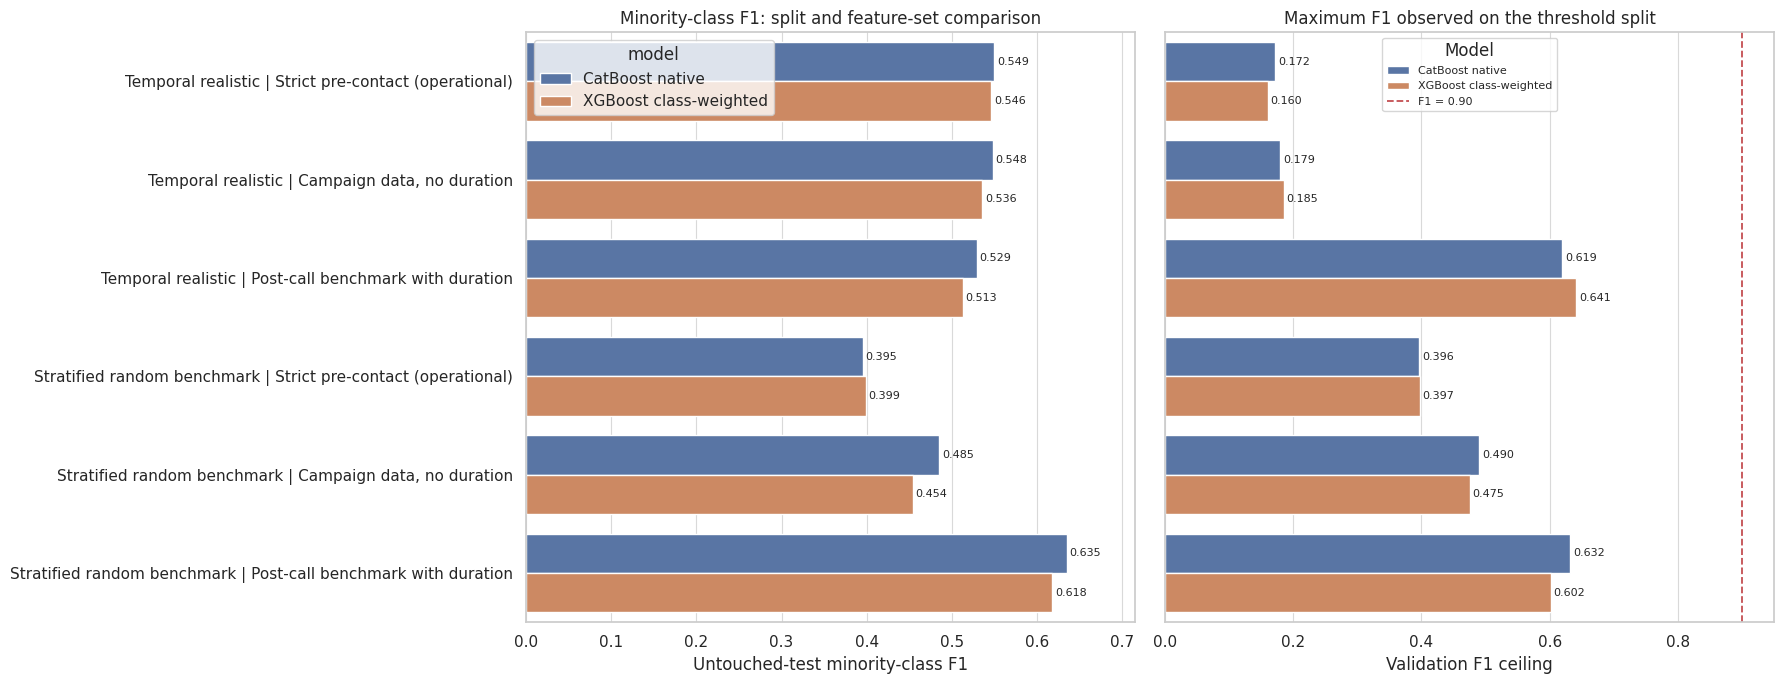

In [ ]:
# Isolate the effects of evaluation design and feature availability for
# models that exist in every matched comparison.
matched_models = ["CatBoost native", "XGBoost class-weighted"]
matched_comparison = advanced_all_results[
    advanced_all_results["model"].isin(matched_models)
].copy()
matched_comparison["configuration"] = (
    matched_comparison["evaluation"]
    + " | "
    + matched_comparison["feature_set"]
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
sns.barplot(
    data=matched_comparison,
    y="configuration",
    x="f1",
    hue="model",
    orient="h",
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title("Minority-class F1: split and feature-set comparison")
axes[0].set_xlabel("Untouched-test minority-class F1")
axes[0].set_ylabel("")
axes[0].set_xlim(0, max(0.70, matched_comparison["f1"].max() + 0.08))
axes[0].grid(axis="x", color="#D9D9D9", linewidth=0.8)
axes[0].grid(axis="y", visible=False)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", padding=2, fontsize=8)

sns.barplot(
    data=matched_comparison,
    y="configuration",
    x="validation_f1_ceiling",
    hue="model",
    orient="h",
    errorbar=None,
    ax=axes[1],
)
axes[1].axvline(
    0.90, color="#C44E52", linestyle="--", linewidth=1.3, label="F1 = 0.90"
)
axes[1].set_title("Maximum F1 observed on the threshold split")
axes[1].set_xlabel("Validation F1 ceiling")
axes[1].set_ylabel("")
axes[1].set_xlim(
    0,
    max(0.95, matched_comparison["validation_f1_ceiling"].max() + 0.05),
)
axes[1].grid(axis="x", color="#D9D9D9", linewidth=0.8)
axes[1].grid(axis="y", visible=False)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.3f", padding=2, fontsize=8)

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, title="Model", fontsize=8)
plt.tight_layout()
comparison_path = FIGURE_DIR / "advanced_split_feature_f1_comparison.png"
plt.savefig(comparison_path, dpi=180, bbox_inches="tight")
plt.show()


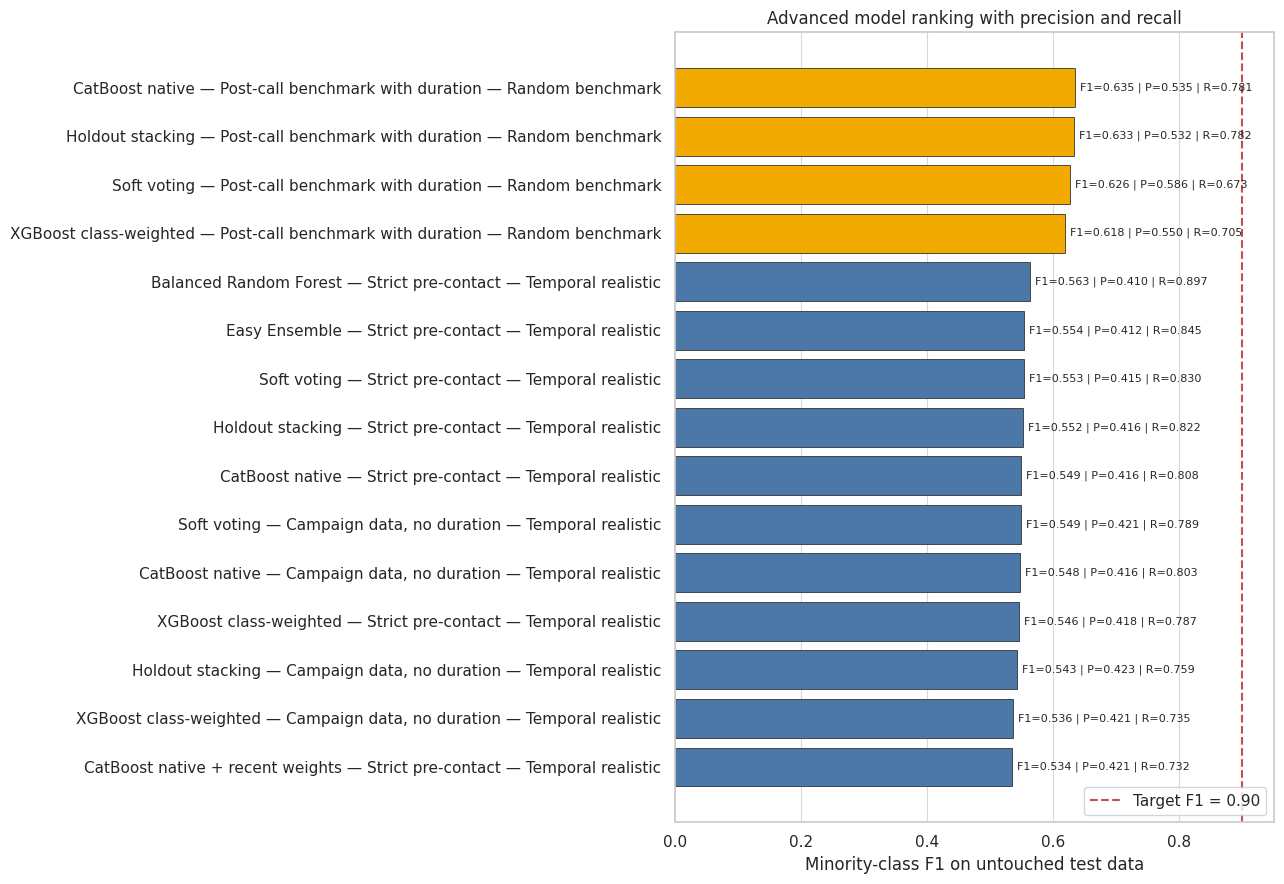

,rank,evaluation,feature_set,model,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,f1,roc_auc,average_precision,validation_f1_ceiling,false_positive,false_negative,true_positive,true_negative
0,1,Stratified random benchmark,Post-call benchmark with duration,CatBoost native,0.6768,0.8952,0.8455,0.5355,0.7806,0.6352,0.9321,0.6323,0.6323,537,174,619,5452
1,2,Stratified random benchmark,Post-call benchmark with duration,Holdout stacking,0.2750,0.8941,0.8454,0.5322,0.7818,0.6333,0.9323,0.6332,0.6337,545,173,620,5444
2,3,Stratified random benchmark,Post-call benchmark with duration,Soft voting,0.6919,0.9061,0.8051,0.5855,0.6734,0.6264,0.9321,0.6294,0.6189,378,259,534,5611
3,4,Stratified random benchmark,Post-call benchmark with duration,XGBoost class-weighted,0.5583,0.8981,0.8143,0.5502,0.7049,0.6180,0.9285,0.6162,0.6017,457,234,559,5532
4,5,Temporal realistic,Strict pre-contact (operational),Balanced Random Forest,0.4322,0.4516,0.5299,0.4100,0.8969,0.5627,0.5575,0.4280,0.1675,3444,275,2393,670
5,6,Temporal realistic,Strict pre-contact (operational),Easy Ensemble,0.4622,0.4643,0.5313,0.4119,0.8452,0.5538,0.5575,0.4300,0.1657,3220,413,2255,894
6,7,Temporal realistic,Strict pre-contact (operational),Soft voting,0.3842,0.4733,0.5360,0.4152,0.8298,0.5535,0.5716,0.4413,0.1732,3118,454,2214,996
7,8,Temporal realistic,Strict pre-contact (operational),Holdout stacking,0.4307,0.4758,0.5367,0.4159,0.8220,0.5523,0.5732,0.4411,0.1752,3080,475,2193,1034
8,9,Temporal realistic,Strict pre-contact (operational),CatBoost native,0.4101,0.4785,0.5365,0.4162,0.8085,0.5495,0.5770,0.4491,0.1716,3026,511,2157,1088
9,10,Temporal realistic,"Campaign data, no duration",Soft voting,0.3721,0.4903,0.5428,0.4211,0.7890,0.5491,0.5758,0.4529,0.1812,2894,563,2105,1220


In [ ]:
ranked_results = advanced_all_results.sort_values(
    ["f1", "average_precision"], ascending=False
).reset_index(drop=True)
ranked_results["rank"] = np.arange(1, len(ranked_results) + 1)
ranked_results["configuration"] = (
    ranked_results["model"]
    + " — "
    + ranked_results["feature_set"].str.replace(
        " (operational)", "", regex=False
    )
    + " — "
    + ranked_results["evaluation"].str.replace(
        "Stratified random benchmark", "Random benchmark", regex=False
    )
)
ranked_results.to_csv(
    TABLE_DIR / "advanced_final_ranked_metrics.csv", index=False
)

top_for_plot = ranked_results.head(15).sort_values("f1", ascending=True)
ranking_colors = top_for_plot["evaluation"].map({
    "Temporal realistic": "#4C78A8",
    "Stratified random benchmark": "#F2A900",
})

fig, ax = plt.subplots(figsize=(13, 9))
bars = ax.barh(
    top_for_plot["configuration"],
    top_for_plot["f1"],
    color=ranking_colors,
    edgecolor="#333333",
    linewidth=0.6,
)
ax.axvline(0.90, color="#C44E52", linestyle="--", label="Target F1 = 0.90")
ax.set_xlim(0, max(0.95, top_for_plot["f1"].max() + 0.10))
ax.set_xlabel("Minority-class F1 on untouched test data")
ax.set_ylabel("")
ax.set_title("Advanced model ranking with precision and recall")
ax.grid(axis="x", color="#D9D9D9", linewidth=0.8)
ax.grid(axis="y", visible=False)
for bar, (_, row) in zip(bars, top_for_plot.iterrows()):
    ax.text(
        bar.get_width() + 0.008,
        bar.get_y() + bar.get_height() / 2,
        f"F1={row['f1']:.3f} | P={row['precision']:.3f} | "
        f"R={row['recall_sensitivity']:.3f}",
        va="center",
        fontsize=8,
    )
ax.legend(loc="lower right")
plt.tight_layout()
ranking_path = FIGURE_DIR / "advanced_final_model_f1_ranking.png"
plt.savefig(ranking_path, dpi=180, bbox_inches="tight")
plt.show()

display(ranked_results[[
    "rank", "evaluation", "feature_set", "model", "threshold",
    "accuracy", "balanced_accuracy", "precision", "recall_sensitivity",
    "f1", "roc_auc", "average_precision", "validation_f1_ceiling",
    "false_positive", "false_negative", "true_positive", "true_negative",
]])


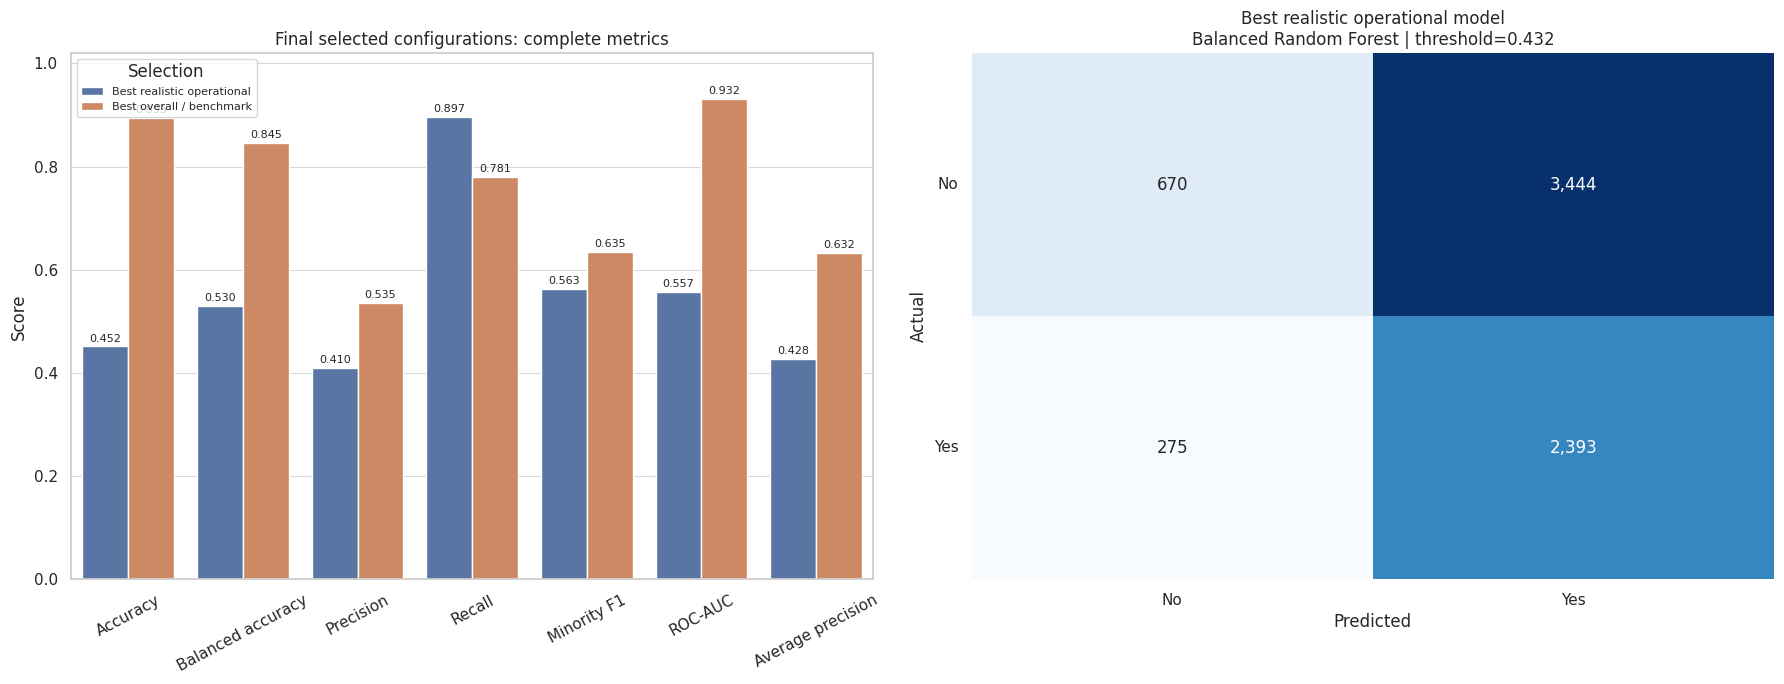

,selection,evaluation,feature_set,model,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,f1,roc_auc,average_precision,validation_f1_ceiling
0,Best realistic operational,Temporal realistic,Strict pre-contact (operational),Balanced Random Forest,0.4322,0.4516,0.5299,0.4100,0.8969,0.5627,0.5575,0.4280,0.1675
1,Best overall / benchmark,Stratified random benchmark,Post-call benchmark with duration,CatBoost native,0.6768,0.8952,0.8455,0.5355,0.7806,0.6352,0.9321,0.6323,0.6323


Maximum validation F1 across advanced experiments: 0.6440
Highest descriptive untouched-test F1: 0.6352
No validation threshold reached F1=0.90. Threshold tuning alone cannot legitimately produce 0.90 from these fitted probability scores.
No untouched-test result reached minority-class F1=0.90. Do not replace minority F1 with accuracy or weighted F1 to claim the target.


In [ ]:
best_overall = ranked_results.iloc[0]
operational_results = ranked_results[
    (ranked_results["evaluation"] == "Temporal realistic")
    & (
        ranked_results["feature_set"]
        == "Strict pre-contact (operational)"
    )
].copy()
if operational_results.empty:
    raise RuntimeError("No realistic strict pre-contact result was produced.")
best_operational = operational_results.iloc[0]

final_selection = pd.DataFrame([
    {"selection": "Best realistic operational", **best_operational.to_dict()},
    {"selection": "Best overall / benchmark", **best_overall.to_dict()},
]).drop_duplicates(
    subset=["evaluation", "feature_set", "model"], keep="first"
)

metric_columns = [
    "accuracy", "balanced_accuracy", "precision",
    "recall_sensitivity", "f1", "roc_auc", "average_precision",
]
metric_labels = {
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced accuracy",
    "precision": "Precision",
    "recall_sensitivity": "Recall",
    "f1": "Minority F1",
    "roc_auc": "ROC-AUC",
    "average_precision": "Average precision",
}
final_long = final_selection.melt(
    id_vars=["selection"],
    value_vars=metric_columns,
    var_name="metric",
    value_name="score",
)
final_long["metric"] = final_long["metric"].map(metric_labels)

operational_key = (
    best_operational["evaluation"],
    best_operational["feature_set"],
    best_operational["model"],
)
operational_predictions = advanced_prediction_store[operational_key]
operational_labels = (
    operational_predictions["probabilities"]
    >= float(best_operational["threshold"])
).astype(int)
operational_cm = confusion_matrix(
    operational_predictions["y_true"],
    operational_labels,
    labels=[0, 1],
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(
    data=final_long,
    x="metric",
    y="score",
    hue="selection",
    errorbar=None,
    ax=axes[0],
)
axes[0].set_ylim(0, 1.02)
axes[0].set_xlabel("")
axes[0].set_ylabel("Score")
axes[0].set_title("Final selected configurations: complete metrics")
axes[0].tick_params(axis="x", rotation=28)
axes[0].grid(axis="y", color="#D9D9D9", linewidth=0.8)
axes[0].grid(axis="x", visible=False)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", padding=2, fontsize=8)
axes[0].legend(title="Selection", fontsize=8)

sns.heatmap(
    operational_cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    ax=axes[1],
)
axes[1].set_title(
    "Best realistic operational model\n"
    f"{best_operational['model']} | threshold={best_operational['threshold']:.3f}"
)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_xticklabels(["No", "Yes"])
axes[1].set_yticklabels(["No", "Yes"], rotation=0)

plt.tight_layout()
final_plot_path = FIGURE_DIR / "advanced_final_selected_model_metrics.png"
plt.savefig(final_plot_path, dpi=180, bbox_inches="tight")
plt.show()

final_selection.to_csv(
    TABLE_DIR / "advanced_final_selected_configurations.csv", index=False
)
display(final_selection[[
    "selection", "evaluation", "feature_set", "model", "threshold",
    "accuracy", "balanced_accuracy", "precision", "recall_sensitivity",
    "f1", "roc_auc", "average_precision", "validation_f1_ceiling",
]])

maximum_validation_f1 = float(
    advanced_all_results["validation_f1_ceiling"].max()
)
maximum_test_f1 = float(advanced_all_results["f1"].max())
print(f"Maximum validation F1 across advanced experiments: {maximum_validation_f1:.4f}")
print(f"Highest descriptive untouched-test F1: {maximum_test_f1:.4f}")
if maximum_validation_f1 < 0.90:
    print(
        "No validation threshold reached F1=0.90. Threshold tuning alone "
        "cannot legitimately produce 0.90 from these fitted probability scores."
    )
if maximum_test_f1 < 0.90:
    print(
        "No untouched-test result reached minority-class F1=0.90. Do not "
        "replace minority F1 with accuracy or weighted F1 to claim the target."
    )
